## Прогнозирование годовых медицинских расходов пациента на основе табличных данных

## Характеристика датасета

Общее количество записей: 5000  
Всего признаков: 20  
Тип данных: Синтетические  
Отсутствующие значения: Нет  

Описание признаков:
1. Демографические признаки:

| Столбец | Описание |
|----------|----------------------|
| **age** | Возраст пациента (18–90 лет) |
| **gender** | Пол пациента (мужской/женский) | 
| **bmi** | Индекс массы тела | 
  

2. Образ жизни и поведение в отношении здоровья

| Столбец | Описание |
|----------|----------------------|
| **smoker** | Статус курения (Да / Нет) |
| **physical_activity_level** | Уровень физической активности (низкий / средний / высокий) | 
| **daily_steps** | Среднее количество шагов в день | 
| **sleep_hours** | Средняя продолжительность сна (в часах) |
| **stress_level** | Уровень стресса по шкале от 1 до 10 | 

3. Медицинские состояния

| Столбец | Описание |
|----------|----------------------|
| **diabetes** | Наличие диабета (0 = Нет, 1 = Да) |
| **hypertension** | Индикатор высокого кровяного давления | 
| **heart_disease** | История сердечных заболеваний | 
| **asthma** | Индикатор состояния астмы |

4. Использование медицинских услуг

| Столбец | Описание |
|----------|----------------------|
| **doctor_visits_per_year** | Количество визитов к врачу в год |
| **hospital_admissions** | Количество госпитализаций | 
| **medication_count** | Количество принимаемых лекарств | 

5. Страхование и местоположение

| Столбец | Описание |
|----------|----------------------|
| **insurance_type** | Вид страхования (Отсутствует / Государственное / Частное) |
| **insurance_coverage_pct** | Процент страхового покрытия | 
| **city_type** | Жилой район (городской / полугородской / сельский) | 

6. Историческая стоимость

| Столбец | Описание |
|----------|----------------------|
| **previous_year_cost** | Медицинские расходы за предыдущий год |

7. Целевая переменная

| Столбец | Описание |
|----------|----------------------|
| **annual_medical_cost** | Общие годовые расходы на медицинское обслуживание (долл. США) |

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import joblib
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, GridSearchCV, ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, make_scorer, mean_squared_error
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.inspection import permutation_importance
try:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner
    OPTUNA_AVAILABLE = True
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    OPTUNA_AVAILABLE = False
    print('Optuna не установлена. Установите: pip install optuna')
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP не установлен. Установите: pip install shap')
try:
    from catboost import CatBoostRegressor, Pool
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost не установлен. Установите: pip install catboost')

Установим random state для воспроизводимости результатов.

In [2]:
RANDOM_STATE = 42

# Exploratory Data Analysis (EDA) 

In [3]:
df = pd.read_csv('../data/medical_cost_prediction_dataset.csv')

df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,0,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77,Urban,15110,3202.52


### Корректировка целевой переменной

Зачем делаем корректировку целевой переменной?

- Изначально annual_medical_cost - это чистые расходы пациента с учётом того, что страховая покрыла insurance_coverage_pct % стоимости. 

- Но для моделирования реального сценария страховщика мы должны получать оценку **полной** стоимости медицинских расходов пациента, чтобы подобрать для него страховку. Поэтому мы восстанавливаем полную стоимость по формуле.

- По этой же причине insurance_type и insurance_coverage_pct исключаются из предикторов, т.к. в реальном сценарии мы предполагаем, что у пациента пока нет никакой страховки.

In [4]:
df["insurance_coverage_pct"] = df["insurance_coverage_pct"].astype(float)

In [5]:
df["annual_medical_cost"] = round(df["annual_medical_cost"] / (1 - df["insurance_coverage_pct"]/100))

In [6]:
df.drop(columns=["insurance_type", "insurance_coverage_pct"], axis=1, inplace=True)

## Базовая проверка качества данных

Приведем признаки smoker и gender к единому виду с остальными бинарными признаками (No = 0, Yes = 1, male = 1, female - 0).

In [7]:
df['smoker'] = df['smoker'].map({'Yes': 1, 'No': 0}).astype('int64')
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0}).astype('int64')

In [8]:
# определяем типы признаков
df.dtypes

age                          int64
gender                       int64
bmi                        float64
smoker                       int64
diabetes                     int64
hypertension                 int64
heart_disease                int64
asthma                       int64
physical_activity_level     object
daily_steps                  int64
sleep_hours                float64
stress_level                 int64
doctor_visits_per_year       int64
hospital_admissions          int64
medication_count             int64
city_type                   object
previous_year_cost           int64
annual_medical_cost        float64
dtype: object

In [9]:
n_rows, n_cols = df.shape

print(f'Размер датасета: {n_rows} строк, {n_cols} колонок')
print(f'Количество полных дублей: {df.duplicated().sum()}')

Размер датасета: 5000 строк, 18 колонок
Количество полных дублей: 0


Данные не содержат повторов. Дополнительная очистка от дубликатов не требуется.

In [10]:
data_quality = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'zero_count': df.eq(0).sum(),
    'zero_pct': (df.eq(0).mean() * 100).round(2),
    'n_unique': df.nunique()
})

data_quality.sort_values(
    by=['missing_count', 'zero_count'],
    ascending=False
)

,dtype,missing_count,missing_pct,zero_count,zero_pct,n_unique
asthma,int64,0,0.0,4518,90.36,2
heart_disease,int64,0,0.0,4289,85.78,2
diabetes,int64,0,0.0,3962,79.24,2
smoker,int64,0,0.0,3779,75.58,2
hypertension,int64,0,0.0,3560,71.20,2
gender,int64,0,0.0,2519,50.38,2
hospital_admissions,int64,0,0.0,1819,36.38,7
medication_count,int64,0,0.0,609,12.18,8
doctor_visits_per_year,int64,0,0.0,81,1.62,15
age,int64,0,0.0,0,0.00,72


Нулевые значения присутствуют только в тех признаках, в которых они могут быть по смыслу.

Краткая статистика по числовым признакам:

In [11]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,5000.0,53.30,20.65,18.0,36.00,53.0,71.00,89.0
gender,5000.0,0.50,0.50,0.0,0.00,0.0,1.00,1.0
bmi,5000.0,25.97,5.05,6.4,22.60,25.9,29.40,43.6
smoker,5000.0,0.24,0.43,0.0,0.00,0.0,0.00,1.0
diabetes,5000.0,0.21,0.41,0.0,0.00,0.0,0.00,1.0
hypertension,5000.0,0.29,0.45,0.0,0.00,0.0,1.00,1.0
heart_disease,5000.0,0.14,0.35,0.0,0.00,0.0,0.00,1.0
asthma,5000.0,0.10,0.30,0.0,0.00,0.0,0.00,1.0
daily_steps,5000.0,7993.22,4052.13,1004.0,4545.00,7989.0,11532.25,14999.0
sleep_hours,5000.0,6.49,1.44,4.0,5.20,6.5,7.70,9.0


 - Подозрительный минимум у признака bmi (индекс массы тела) - 6.4. Это аномально низко, т.к. обычный диапазон 16-40. Это может быть ошибкой ввода или экстремальным случаем;
 - Правостороннее распределение по целевой переменной. Есть небольшая группа людей с высокими расходами;
 - Большой разброс значений (age: 18-89, annual_medical_cost: 404 - 44792). Для моделей, чувствительных к масштабу (SVM, KNN, Neural Networks, Linear Regression), потребуется нормализация (MinMaxScaler) или стандартизация (StandardScaler).

In [12]:
target_col = 'annual_medical_cost'

# Числовые признаки
numeric_features = [
    'age',
    'bmi',
    'daily_steps',
    'sleep_hours',
    'doctor_visits_per_year',
    'hospital_admissions',
    'medication_count',
    'previous_year_cost',
    'stress_level'
]

# Бинарные признаки, уже закодированные как 0/1
binary_features = [
    'gender',
    'smoker',
    'diabetes',
    'hypertension',
    'heart_disease',
    'asthma'
]

# Номинальные категориальные признаки с несколькими категориями
categorical_features = [
    'physical_activity_level',
    'city_type'
]

# Все признаки для модели
feature_cols = numeric_features + binary_features + categorical_features

# Признаки для анализа распределений
continuous_features = [
    'age',
    'bmi',
    'daily_steps',
    'sleep_hours',
    'previous_year_cost',
    'annual_medical_cost'
]

# Дискретные числовые признаки
count_features = [
    'doctor_visits_per_year',
    'hospital_admissions',
    'medication_count',
    'stress_level'
]

# Категориальные признаки для countplot / barplot
cat_features_for_eda = binary_features + categorical_features

## 1. Визуализации числовых и категориальных переменных

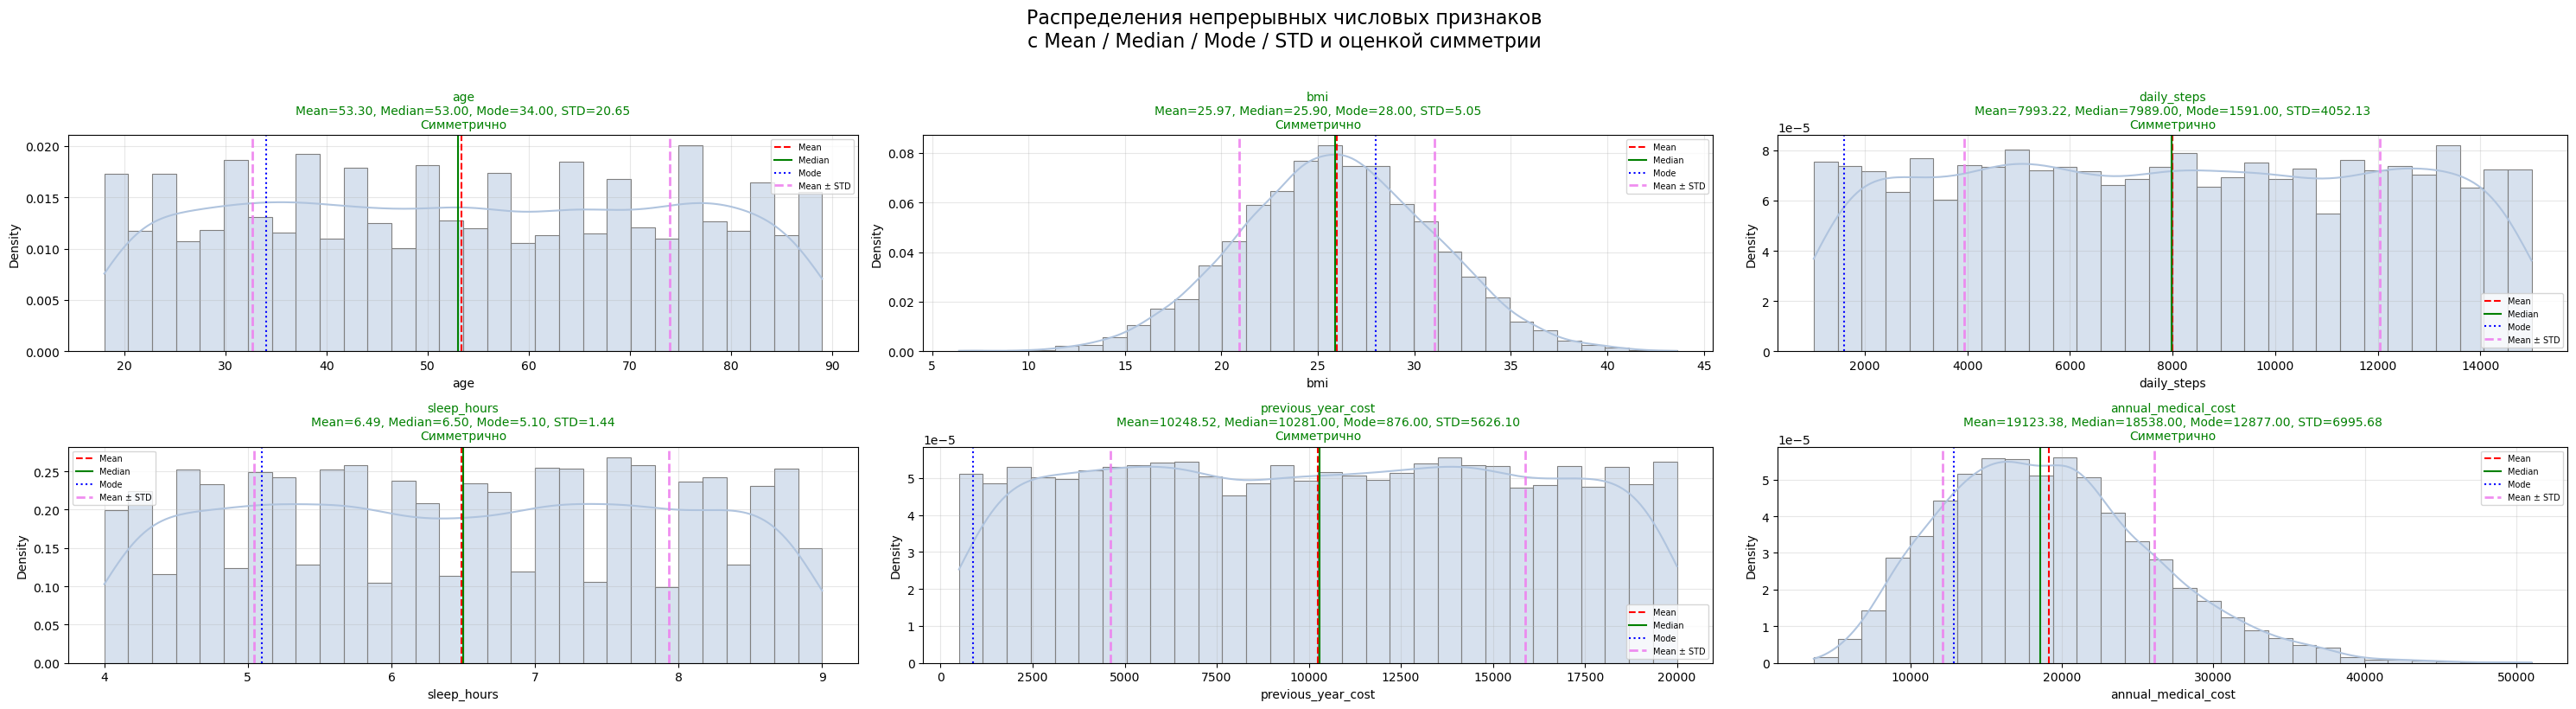

In [13]:
# Распределения непрерывных числовых признаков
# Смотрим форму распределения, среднее, медиану, моду и стандартное отклонение

plot_features = continuous_features

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(plot_features):
    data = df[col].dropna()

    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode().iloc[0] if not data.mode().empty else np.nan
    std_val = data.std()

    # Простая оценка асимметрии через разницу среднего и медианы
    diff = abs(mean_val - median_val)
    skew_ratio = diff / std_val if std_val != 0 else 0

    if skew_ratio < 0.1:
        color = 'green'
        label = 'Симметрично'
    elif skew_ratio < 0.3:
        color = 'goldenrod'
        label = 'Умеренная асимметрия'
    else:
        color = 'crimson'
        label = 'Сильная асимметрия'

    sns.histplot(
        data,
        bins=30,
        kde=True,
        color='lightsteelblue',
        edgecolor='gray',
        linewidth=0.8,
        ax=axes[i],
        stat='density'
    )

    # Основные статистики на графике
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')
    axes[i].axvline(mode_val, color='blue', linestyle=':', linewidth=1.5, label='Mode')

    # Интервал mean ± std
    axes[i].axvline(
        mean_val + std_val,
        color='violet',
        linestyle='--',
        linewidth=2,
        alpha=0.9,
        label='Mean ± STD'
    )
    axes[i].axvline(
        mean_val - std_val,
        color='violet',
        linestyle='--',
        linewidth=2,
        alpha=0.9
    )

    axes[i].set_title(
        (
            f'{col}\n'
            f'Mean={mean_val:.2f}, Median={median_val:.2f}, '
            f'Mode={mode_val:.2f}, STD={std_val:.2f}\n'
            f'{label}'
        ),
        fontsize=10,
        color=color
    )

    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=7)

# Удаляем пустые оси, если количество графиков не кратно n_cols
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Распределения непрерывных числовых признаков\n'
    'с Mean / Median / Mode / STD и оценкой симметрии',
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- Распределения `age`, `daily_steps`, `sleep_hours` и `previous_year_cost` выглядят близкими к равномерным, без выраженной асимметрии.

- `bmi` имеет форму, близкую к нормальному распределению.

- Целевая переменная `annual_medical_cost` визуально имеет правый хвост: у большинства пациентов расходы находятся в среднем диапазоне, но есть группа с заметно более высокими затратами. Для неё при моделировании может быть полезно дополнительно проверить выбросы и, возможно, логарифмирование таргета.

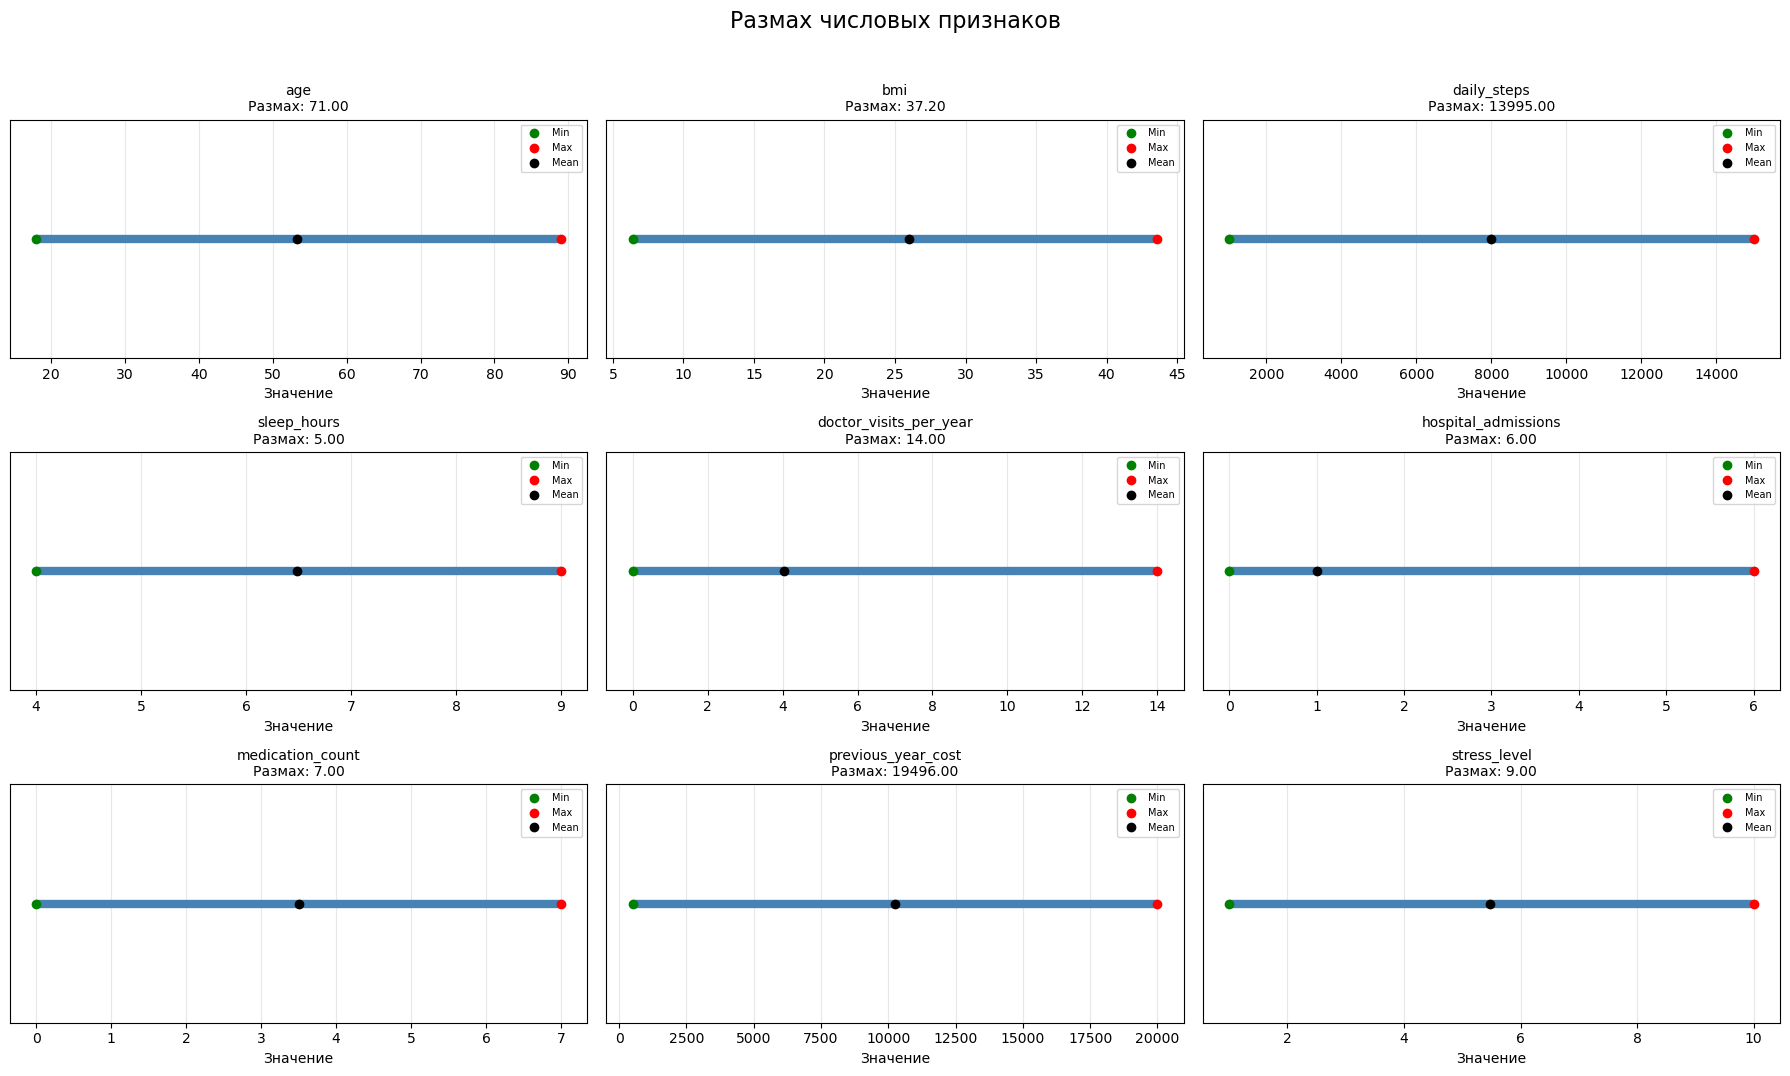

In [14]:
# Размах числовых признаков
# Смотрим минимальное, максимальное и среднее значение по каждому числовому признаку

plot_features = numeric_features

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 3.5 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(plot_features):
    data = df[col].dropna()

    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()
    range_val = max_val - min_val

    # Линия от минимального до максимального значения
    axes[i].hlines(
        y=1,
        xmin=min_val,
        xmax=max_val,
        color='steelblue',
        linewidth=6
    )

    # Отмечаем min / max / mean
    axes[i].plot(min_val, 1, 'go', label='Min')
    axes[i].plot(max_val, 1, 'ro', label='Max')
    axes[i].plot(mean_val, 1, 'ko', label='Mean')

    axes[i].set_title(
        f'{col}\nРазмах: {range_val:.2f}',
        fontsize=10
    )

    axes[i].set_yticks([])
    axes[i].set_xlabel('Значение')
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].legend(fontsize=7, loc='upper right')

# Удаляем пустые оси, если графиков меньше, чем ячеек сетки
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Размах числовых признаков',
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- Все числовые признаки находятся в ожидаемых диапазонах и не выглядят ошибочными по min/max значениям.

- `age`, `bmi`, `daily_steps`, `sleep_hours` и `previous_year_cost` имеют достаточно широкий разброс, поэтому для линейных моделей может быть полезно масштабирование.

- Дискретные признаки `doctor_visits_per_year`, `hospital_admissions`, `medication_count` и `stress_level` имеют ограниченный диапазон значений, что соответствует их смыслу.

- У признаков `daily_steps` и `previous_year_cost` размах заметно больше, чем у остальных, поэтому они могут сильнее влиять на модели, чувствительные к масштабу признаков.

- Для деревянных моделей масштабирование не является обязательным, но для линейных моделей его лучше добавить в preprocessing pipeline.

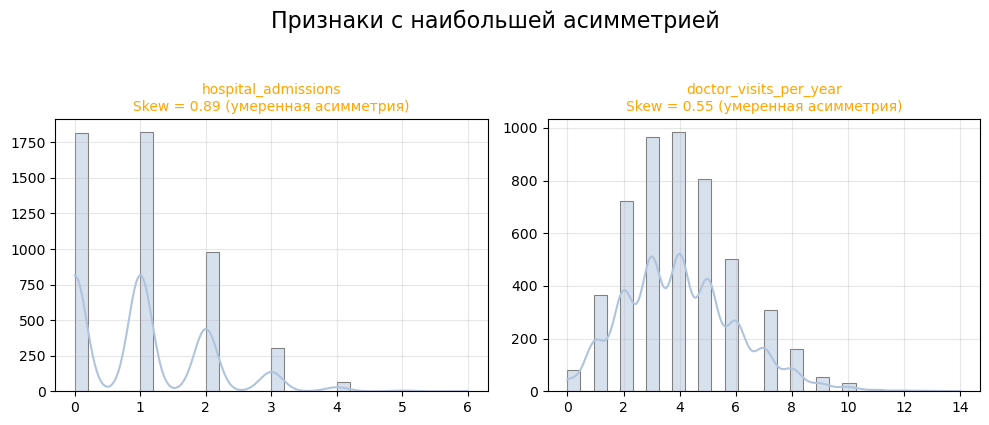

,skew
hospital_admissions,0.889
doctor_visits_per_year,0.551


In [15]:
# Признаки с наибольшей асимметрией
# Ищем числовые признаки, распределение которых заметно отклоняется от симметричного

skew_threshold = 0.5
top_n = 4

# Считаем коэффициент асимметрии по числовым признакам
skew_values = df[numeric_features].skew()

# Оставляем признаки с заметной асимметрией
skewed_features = skew_values[skew_values.abs() > skew_threshold]

# Сортируем по абсолютной величине асимметрии
skewed_features = skewed_features.reindex(
    skewed_features.abs().sort_values(ascending=False).index
)

# Берём несколько наиболее "проблемных" признаков для визуализации
plot_features = skewed_features.head(top_n).index.tolist()

if len(plot_features) == 0:
    print(f'Признаков с |skew| > {skew_threshold} не найдено.')
else:
    fig, axes = plt.subplots(
        1,
        len(plot_features),
        figsize=(5 * len(plot_features), 4)
    )

    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, plot_features):
        data = df[col].dropna()
        skew_val = data.skew()

        sns.histplot(
            data,
            bins=30,
            kde=True,
            ax=ax,
            color='lightsteelblue',
            edgecolor='gray'
        )

        # Оцениваем степень асимметрии
        if abs(skew_val) < 0.3:
            color = 'green'
            skew_label = 'симметричное'
        elif abs(skew_val) < 1:
            color = 'orange'
            skew_label = 'умеренная асимметрия'
        else:
            color = 'red'
            skew_label = 'сильная асимметрия'

        ax.set_title(
            f'{col}\nSkew = {skew_val:.2f} ({skew_label})',
            fontsize=10,
            color=color
        )
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.grid(alpha=0.3)

    fig.suptitle('Признаки с наибольшей асимметрией', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Таблица со значениями асимметрии
skewed_features.to_frame(name='skew').round(3)

- Наибольшая асимметрия наблюдается у признаков `hospital_admissions` и `doctor_visits_per_year`.

- Оба признака имеют умеренную положительную асимметрию: большинство пациентов имеют небольшое число госпитализаций и визитов к врачу, а высокие значения встречаются заметно реже.

- Для `hospital_admissions` распределение особенно скошено вправо: основная масса значений сосредоточена в диапазоне 0–2 госпитализаций.

- `doctor_visits_per_year` распределён более плавно, но также имеет правый хвост за счёт пациентов с большим числом визитов.

- Для линейных моделей эти признаки можно дополнительно проверить на необходимость преобразования, а для деревянных моделей специальная обработка асимметрии не требуется.

In [16]:
# Разделяем числовые признаки по степени асимметрии
# Это пригодится дальше для preprocessing pipeline линейных моделей

skew_threshold = 0.5

skew_values = df[numeric_features].skew()

numeric_skewed = skew_values[
    skew_values.abs() > skew_threshold
].index.tolist()

numeric_standard = [
    col for col in numeric_features
    if col not in numeric_skewed
]

print(f'Признаки с заметной асимметрией: {numeric_skewed}')
print(f'Остальные числовые признаки: {numeric_standard}')

Признаки с заметной асимметрией: ['doctor_visits_per_year', 'hospital_admissions']
Остальные числовые признаки: ['age', 'bmi', 'daily_steps', 'sleep_hours', 'medication_count', 'previous_year_cost', 'stress_level']


In [17]:
# Поиск потенциальных выбросов по IQR-методу
# Метод считает границы нормального диапазона: [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]

def get_iqr_outlier_info(data, column):
    values = data[column].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (values < lower_bound) | (values > upper_bound)
    outliers_count = outlier_mask.sum()

    return {
        'feature': column,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_count': outliers_count,
        'outliers_pct': outliers_count / len(values) * 100
    }


# Считаем информацию по всем числовым признакам
outliers_info = pd.DataFrame([
    get_iqr_outlier_info(df, col)
    for col in numeric_features
])

# Округляем числовые значения для более удобного отображения
outliers_info = outliers_info.round({
    'q1': 2,
    'q3': 2,
    'iqr': 2,
    'lower_bound': 2,
    'upper_bound': 2,
    'outliers_pct': 2
})

# Сортируем по доле потенциальных выбросов
outliers_info = outliers_info.sort_values(
    by='outliers_pct',
    ascending=False
)

outliers_info

,feature,q1,q3,iqr,lower_bound,upper_bound,outliers_count,outliers_pct
4,doctor_visits_per_year,3.00,5.00,2.00,0.00,8.00,105,2.10
1,bmi,22.60,29.40,6.80,12.40,39.60,39,0.78
5,hospital_admissions,0.00,2.00,2.00,-3.00,5.00,2,0.04
0,age,36.00,71.00,35.00,-16.50,123.50,0,0.00
2,daily_steps,4545.00,11532.25,6987.25,-5935.88,22013.12,0,0.00
3,sleep_hours,5.20,7.70,2.50,1.45,11.45,0,0.00
6,medication_count,1.00,6.00,5.00,-6.50,13.50,0,0.00
7,previous_year_cost,5342.75,15034.50,9691.75,-9194.88,29572.12,0,0.00
8,stress_level,3.00,8.00,5.00,-4.50,15.50,0,0.00


- IQR-метод нашёл потенциальные выбросы только в трёх признаках: `doctor_visits_per_year`, `bmi` и `hospital_admissions`.

- Больше всего потенциальных выбросов у `doctor_visits_per_year`: 105 наблюдений, или 2.1% датасета. При этом значения выше 8 визитов в год не обязательно являются ошибками — для части пациентов это может быть нормальной ситуацией.

- У `bmi` найдено 39 потенциальных выбросов, или 0.78% датасета. Нижние экстремальные значения BMI могут быть подозрительными, а верхние значения выше 39.6 выглядят редкими, но медицински возможными.

- У `hospital_admissions` найдено всего 2 потенциальных выброса, или 0.04% датасета. Такие значения лучше оставить, так как редкие госпитализации могут отражать реальные тяжёлые случаи.

- По остальным числовым признакам IQR-метод не выявил выбросов.

- На этом этапе выбросы не удаляем автоматически: большинство найденных значений могут быть валидными медицинскими наблюдениями. Отдельного внимания требует только `bmi`, для которого стоит проверить минимальные значения и при необходимости обработать явно некорректные наблюдения.

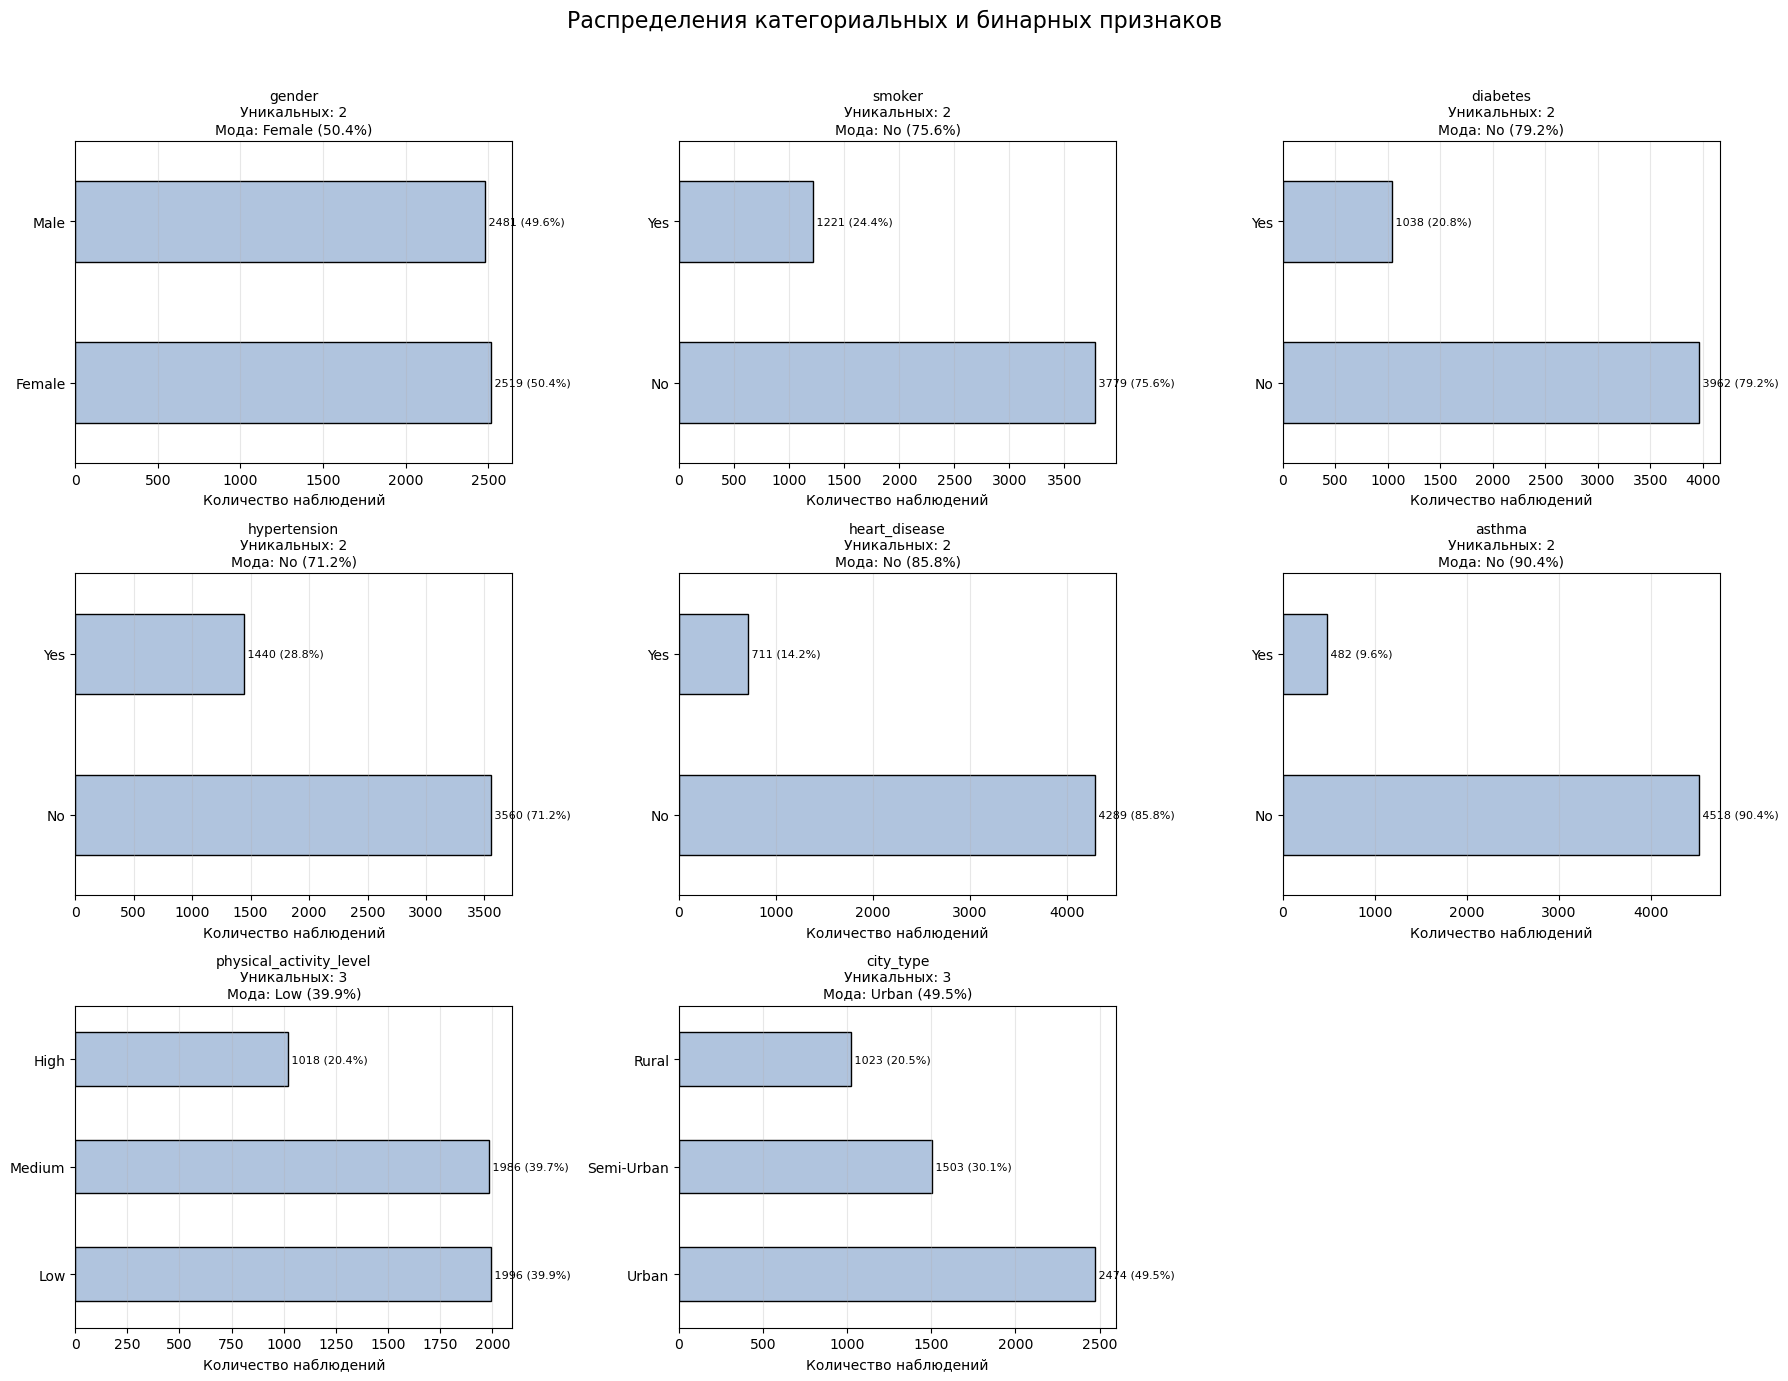

In [18]:
# Распределения категориальных и бинарных признаков
# Смотрим баланс категорий и долю самой частой категории

plot_features = cat_features_for_eda

# Читаемые подписи для бинарных признаков
binary_value_labels = {
    'gender': {0: 'Female', 1: 'Male'},
    'smoker': {0: 'No', 1: 'Yes'},
    'diabetes': {0: 'No', 1: 'Yes'},
    'hypertension': {0: 'No', 1: 'Yes'},
    'heart_disease': {0: 'No', 1: 'Yes'},
    'asthma': {0: 'No', 1: 'Yes'}
}

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(plot_features):
    # Для бинарных признаков заменяем 0/1 на понятные подписи
    if col in binary_value_labels:
        plot_data = df[col].map(binary_value_labels[col])
    else:
        plot_data = df[col]

    # Учитываем пропуски как отдельную категорию, если они есть
    plot_data = plot_data.fillna('Missing')

    counts = plot_data.value_counts()
    percents = counts / len(df) * 100

    counts.plot(
        kind='barh',
        color='lightsteelblue',
        edgecolor='black',
        ax=axes[i]
    )

    mode_val = counts.index[0]
    mode_percent = percents.iloc[0]

    axes[i].set_title(
        f'{col}\n'
        f'Уникальных: {plot_data.nunique()}\n'
        f'Мода: {mode_val} ({mode_percent:.1f}%)',
        fontsize=10
    )

    axes[i].set_xlabel('Количество наблюдений')
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', alpha=0.3)

    # Подписываем значения на барах
    for j, value in enumerate(counts):
        axes[i].text(
            value,
            j,
            f' {value} ({percents.iloc[j]:.1f}%)',
            va='center',
            fontsize=8
        )

# Удаляем пустые оси
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Распределения категориальных и бинарных признаков',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

- Распределение `gender` практически сбалансировано: доли мужчин и женщин почти одинаковые.

- По признакам `smoker`, `diabetes`, `hypertension`, `heart_disease` и `asthma` наблюдается дисбаланс классов: положительный класс встречается заметно реже отрицательного.

- Самый выраженный дисбаланс среди бинарных признаков — у `asthma` и `heart_disease`: пациентов с этими диагнозами существенно меньше.

- Признак `physical_activity_level` распределён достаточно равномерно между категориями `Low` и `Medium`, при этом категория `High` встречается реже.

- В `city_type` почти половина наблюдений относится к `Urban`, а категории `Semi-Urban` и `Rural` представлены заметно меньше.

- В целом категориальные признаки выглядят валидно: редких единичных категорий или явных ошибок в значениях не видно.

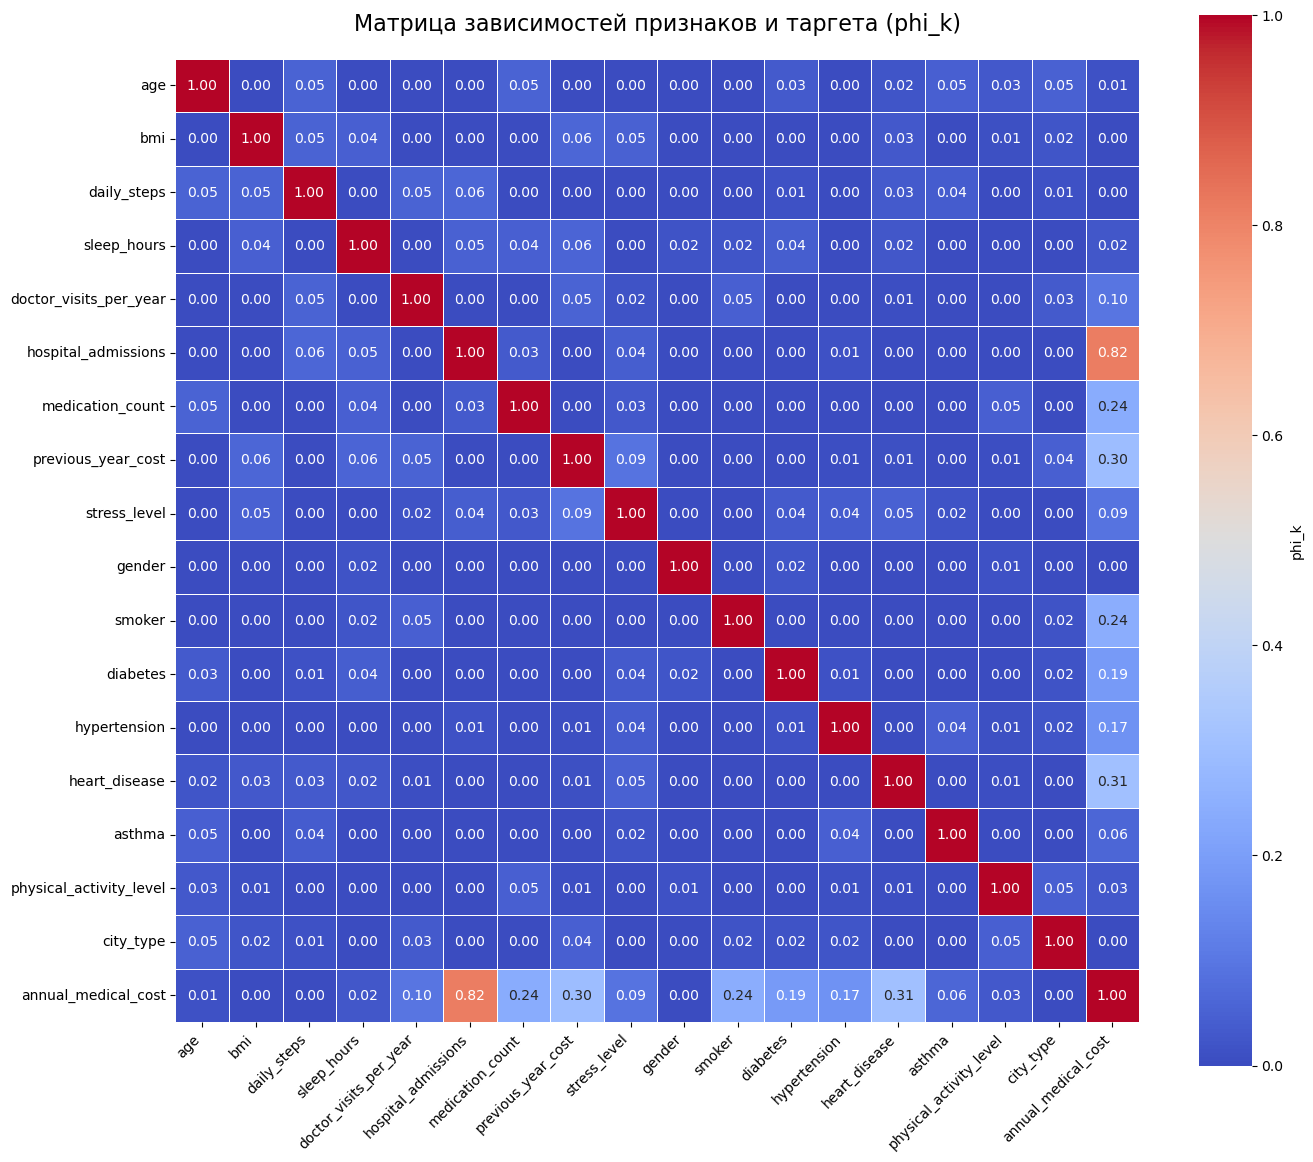

In [19]:
# Матрица зависимостей phi_k
# Позволяет оценивать связи между числовыми, бинарными и категориальными признаками,
# включая нелинейные зависимости

phik_features = feature_cols + [target_col]

phik_data = df[phik_features].copy()

# Бинарные признаки явно приводим к category,
# чтобы phi_k не интерпретировал их как непрерывные числовые признаки
for col in binary_features + categorical_features:
    phik_data[col] = phik_data[col].astype('category')

# Интервальными считаем только настоящие числовые признаки и таргет
interval_cols = numeric_features + [target_col]

phik_matrix = phik_data.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(14, 12))

sns.heatmap(
    phik_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'phi_k'}
)

plt.title('Матрица зависимостей признаков и таргета (phi_k)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- Самая сильная связь с целевой переменной `annual_medical_cost` наблюдается у признака `hospital_admissions` (`phi_k = 0.82`). Это ожидаемо: госпитализации обычно существенно увеличивают медицинские расходы.

- Также заметная связь с таргетом есть у `heart_disease` (`phi_k = 0.31`), `previous_year_cost` (`phi_k = 0.30`), `medication_count` (`phi_k = 0.24`) и `smoker` (`phi_k = 0.24`).

- Медицинские признаки в целом сильнее связаны с расходами, чем демографические и поведенческие признаки.

- Признаки `age`, `bmi`, `daily_steps`, `sleep_hours`, `gender`, `physical_activity_level` и `city_type` почти не показывают прямой зависимости с таргетом по phi_k.

- Между самими признаками сильных зависимостей почти нет, что снижает риск выраженной мультиколлинеарности.

- Для моделирования наиболее важными кандидатами выглядят признаки, связанные с состоянием здоровья и медицинской историей пациента: `hospital_admissions`, `heart_disease`, `previous_year_cost`, `medication_count`, `smoker`, `diabetes` и `hypertension`.

## 2. Анализ целевой переменной

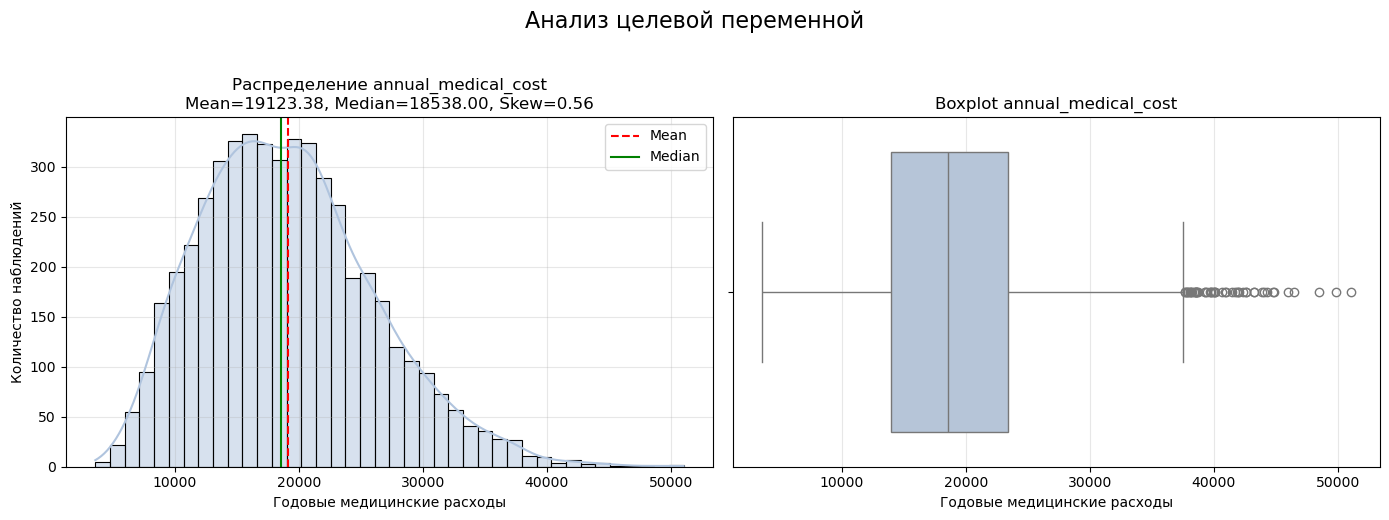

In [20]:
# Анализ распределения целевой переменной
# Смотрим форму распределения, асимметрию, основные статистики и возможные выбросы

target_data = df[target_col].dropna()

mean_val = target_data.mean()
median_val = target_data.median()
std_val = target_data.std()
skew_val = target_data.skew()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Распределение таргета
sns.histplot(
    target_data,
    bins=40,
    kde=True,
    color='lightsteelblue',
    edgecolor='black',
    ax=axes[0]
)

axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
axes[0].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')

axes[0].set_title(
    f'Распределение {target_col}\n'
    f'Mean={mean_val:.2f}, Median={median_val:.2f}, Skew={skew_val:.2f}',
    fontsize=12
)
axes[0].set_xlabel('Годовые медицинские расходы')
axes[0].set_ylabel('Количество наблюдений')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot таргета
sns.boxplot(
    x=target_data,
    color='lightsteelblue',
    ax=axes[1]
)

axes[1].set_title(
    f'Boxplot {target_col}',
    fontsize=12
)
axes[1].set_xlabel('Годовые медицинские расходы')
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle(
    'Анализ целевой переменной',
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

In [21]:
# Краткая статистика по целевой переменной

target_summary = pd.DataFrame({
    'count': [target_data.count()],
    'mean': [target_data.mean()],
    'median': [target_data.median()],
    'std': [target_data.std()],
    'min': [target_data.min()],
    'max': [target_data.max()],
    'skew': [target_data.skew()]
})

target_summary.round(2)

,count,mean,median,std,min,max,skew
0,5000,19123.38,18538.0,6995.68,3594.0,51016.0,0.56


- Целевая переменная `annual_medical_cost` содержит 5000 наблюдений без пропусков.

- Среднее значение расходов составляет около 19 123, медиана — около 18 538. Среднее немного выше медианы, что указывает на умеренный правый хвост распределения.

- Стандартное отклонение достаточно большое — около 6 996, то есть расходы пациентов заметно различаются между собой.

- Минимальное значение равно 3 594, максимальное — 51 016. Диапазон значений широкий, но экстремально аномальных значений по базовой статистике не видно.

- Коэффициент асимметрии равен 0.56, что говорит об умеренной положительной асимметрии: у части пациентов медицинские расходы заметно выше основной массы наблюдений.

- Для линейных моделей можно дополнительно проверить вариант с логарифмированием таргета, а для деревянных моделей можно оставить таргет в исходном масштабе.

In [22]:
# Оцениваем связь каждого признака с целевой переменной
# Используем phi_k, так как он умеет учитывать числовые, бинарные,
# категориальные и потенциально нелинейные зависимости

phik_features = feature_cols + [target_col]

phik_data = df[phik_features].copy()

# Бинарные и категориальные признаки явно приводим к category
for col in binary_features + categorical_features:
    phik_data[col] = phik_data[col].astype('category')

# Интервальными считаем только настоящие числовые признаки и таргет
interval_cols = numeric_features + [target_col]

phik_matrix = phik_data.phik_matrix(interval_cols=interval_cols)

# Достаём связи признаков с таргетом и убираем сам таргет
target_phik = (
    phik_matrix[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

target_phik.round(3)

hospital_admissions        0.816
heart_disease              0.308
previous_year_cost         0.295
smoker                     0.244
medication_count           0.241
diabetes                   0.188
hypertension               0.165
doctor_visits_per_year     0.096
stress_level               0.091
asthma                     0.060
physical_activity_level    0.029
sleep_hours                0.024
age                        0.013
gender                     0.000
bmi                        0.000
daily_steps                0.000
city_type                  0.000
Name: annual_medical_cost, dtype: float64

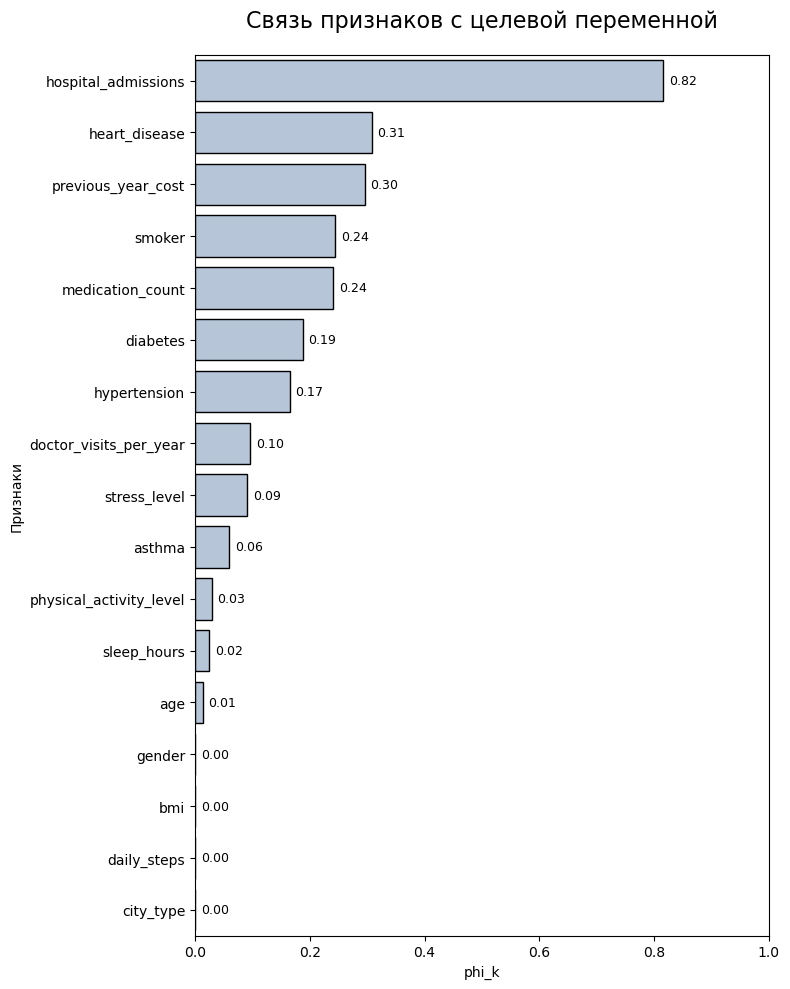

In [23]:
# Связь признаков с целевой переменной

target_phik = (
    phik_matrix[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 10))

ax = sns.barplot(
    x=target_phik.values,
    y=target_phik.index,
    orient='h',
    color='lightsteelblue',
    edgecolor='black'
)

ax.set_title(
    'Связь признаков с целевой переменной',
    fontsize=16,
    pad=20
)
ax.set_xlabel('phi_k')
ax.set_ylabel('Признаки')
ax.set_xlim(0, 1)

# Подписываем значения на барах
for i, value in enumerate(target_phik.values):
    ax.text(
        value + 0.01,
        i,
        f'{value:.2f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

- Наиболее сильная связь с целевой переменной наблюдается у `hospital_admissions` (`phi_k = 0.82`). Этот признак выглядит главным кандидатом на высокую важность в модели.

- Умеренная связь с таргетом есть у медицинских признаков `heart_disease`, `previous_year_cost`, `smoker`, `medication_count`, `diabetes` и `hypertension`.

- Поведенческие и демографические признаки в целом связаны с расходами слабее: `stress_level`, `asthma`, `physical_activity_level`, `sleep_hours` и `age` имеют низкие значения `phi_k`.

- Признаки `gender`, `bmi`, `daily_steps` и `city_type` почти не показывают самостоятельной связи с таргетом по метрике phi_k.

- Для моделирования стоит сохранить все признаки: слабая индивидуальная связь не означает, что признак бесполезен в комбинации с другими признаками.

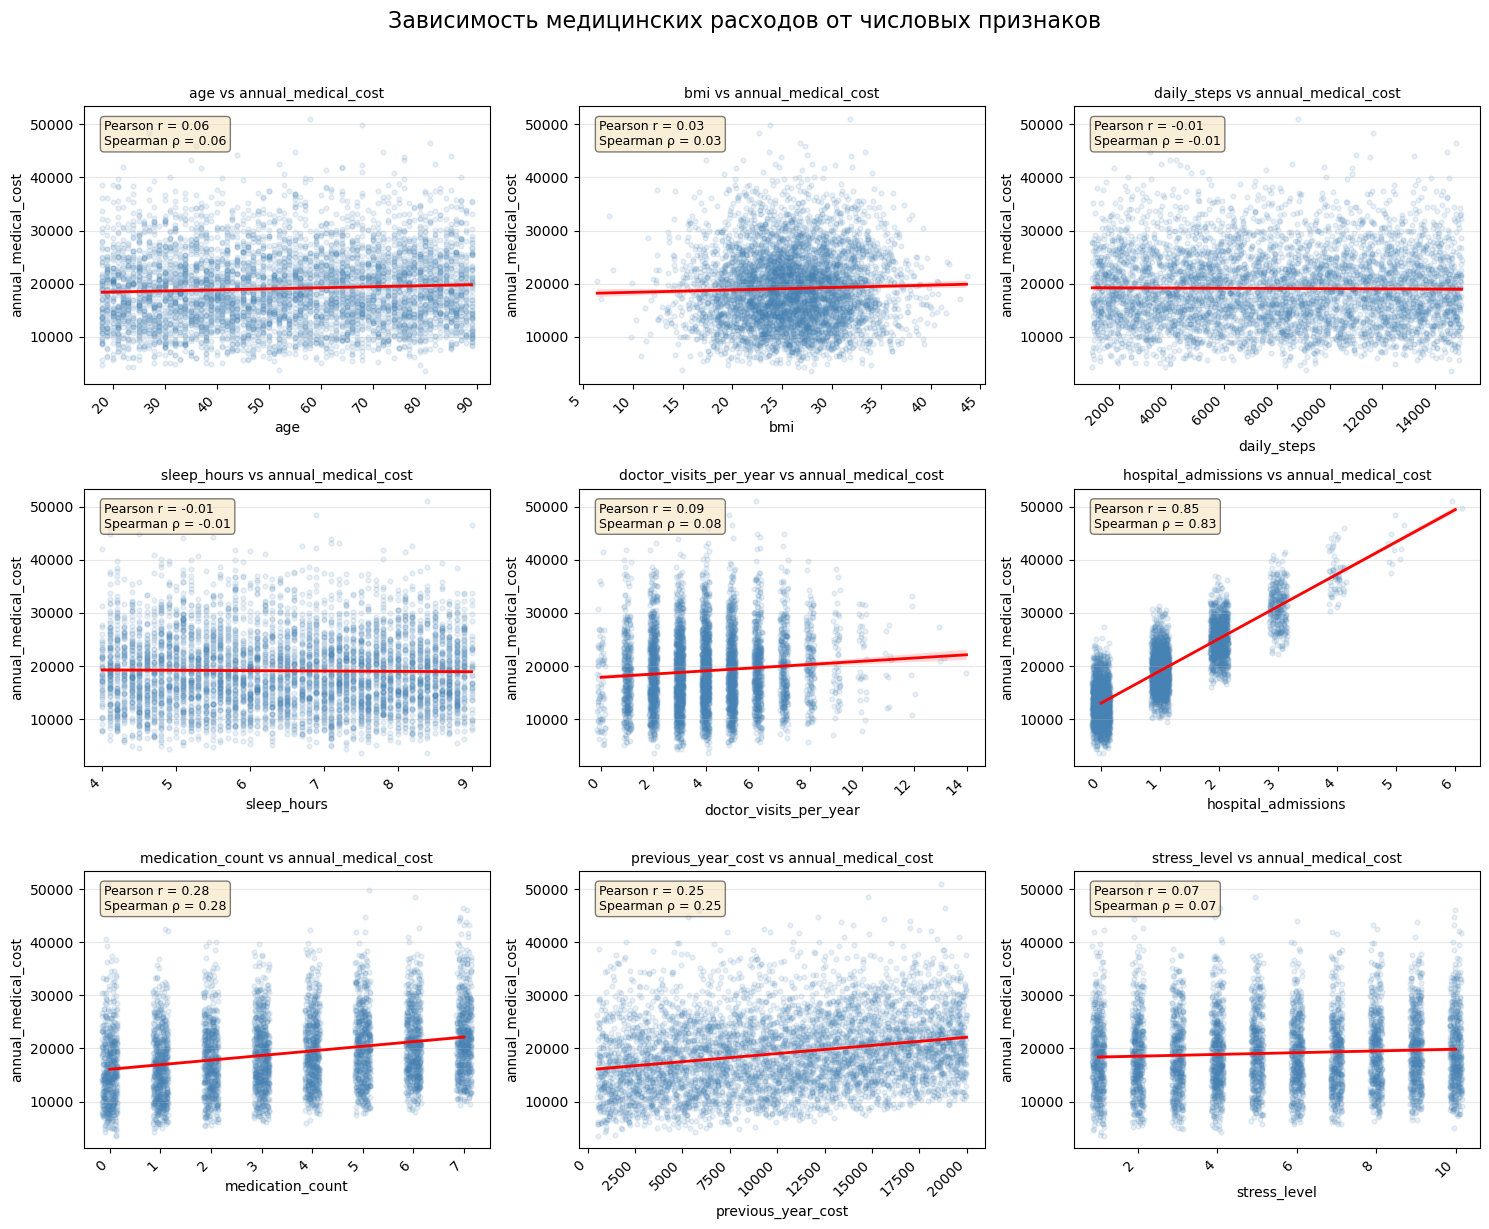

In [24]:
# Связь числовых признаков с целевой переменной
# Смотрим scatterplot + линейный тренд, а также Pearson и Spearman корреляции

plot_features = numeric_features

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, feature in enumerate(plot_features):
    ax = axes[i]

    # Для дискретных признаков добавляем небольшой jitter,
    # чтобы точки не накладывались строго друг на друга
    x_jitter = 0.15 if feature in count_features else None

    sns.regplot(
        data=df,
        x=feature,
        y=target_col,
        scatter_kws={
            'alpha': 0.12,
            's': 12,
            'color': 'steelblue'
        },
        line_kws={
            'color': 'red',
            'linewidth': 2
        },
        x_jitter=x_jitter,
        ax=ax
    )

    pearson_corr = df[[feature, target_col]].corr(method='pearson').iloc[0, 1]
    spearman_corr = df[[feature, target_col]].corr(method='spearman').iloc[0, 1]

    ax.text(
        0.05,
        0.95,
        f'Pearson r = {pearson_corr:.2f}\nSpearman ρ = {spearman_corr:.2f}',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )
    )

    ax.set_title(
        f'{feature} vs {target_col}',
        fontsize=10
    )
    ax.set_xlabel(feature)
    ax.set_ylabel(target_col)
    ax.grid(axis='y', alpha=0.3)

    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

# Удаляем пустые оси
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Зависимость медицинских расходов от числовых признаков',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

- Самая сильная зависимость с таргетом наблюдается у `hospital_admissions`: Pearson = 0.85, Spearman = 0.83. Чем больше госпитализаций, тем выше годовые медицинские расходы.

- У `medication_count` и `previous_year_cost` видна умеренная положительная связь с расходами: пациенты с большим количеством лекарств и более высокими расходами в прошлом году в среднем имеют более высокие текущие расходы.

- `doctor_visits_per_year` имеет слабую положительную линейную связь с таргетом. Несмотря на это, признак всё равно может быть полезен модели, особенно в комбинации с другими медицинскими признаками.

- `age`, `bmi`, `daily_steps`, `sleep_hours` и `stress_level` почти не показывают выраженной линейной или монотонной связи с целевой переменной.

- Для части признаков зависимость может быть нелинейной или проявляться через взаимодействия с другими факторами, поэтому на этом этапе не стоит исключать признаки только по низкой корреляции.

- Основные числовые признаки-кандидаты на высокую важность в модели: `hospital_admissions`, `medication_count` и `previous_year_cost`.

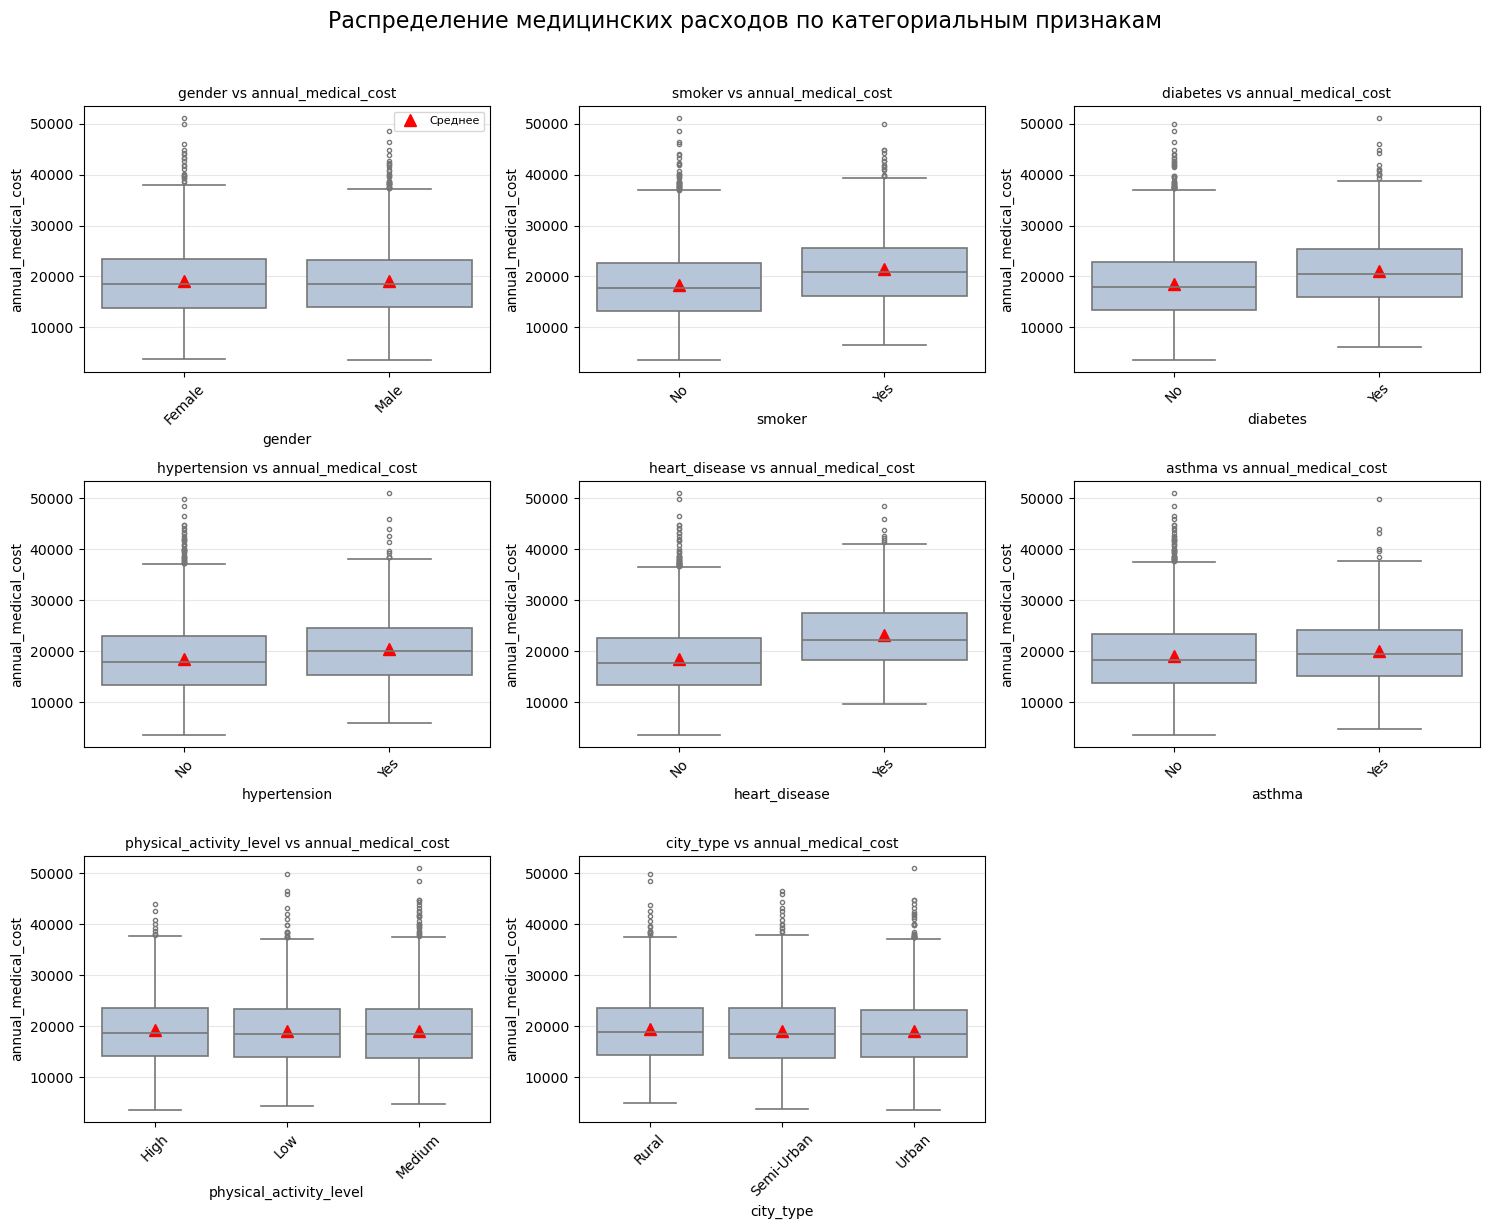

In [25]:
# Зависимость целевой переменной от категориальных и бинарных признаков
# Смотрим, как распределяются медицинские расходы в разных категориях признаков

plot_features = cat_features_for_eda

# Копия датафрейма только для визуализации
plot_df = df.copy()

# Читаемые подписи для бинарных признаков
binary_value_labels = {
    'gender': {0: 'Female', 1: 'Male'},
    'smoker': {0: 'No', 1: 'Yes'},
    'diabetes': {0: 'No', 1: 'Yes'},
    'hypertension': {0: 'No', 1: 'Yes'},
    'heart_disease': {0: 'No', 1: 'Yes'},
    'asthma': {0: 'No', 1: 'Yes'}
}

# Заменяем 0/1 на текстовые категории только для графиков
for col, mapping in binary_value_labels.items():
    plot_df[col] = plot_df[col].map(mapping)

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(plot_features):
    ax = axes[i]

    # Учитываем пропуски как отдельную категорию, если они есть
    plot_df[col] = plot_df[col].fillna('Missing')

    # Средние значения таргета по категориям
    means = plot_df.groupby(col, observed=False)[target_col].mean()

    # Порядок категорий на графике
    order = means.index.tolist()

    sns.boxplot(
        data=plot_df,
        x=col,
        y=target_col,
        order=order,
        color='lightsteelblue',
        fliersize=3,
        linewidth=1.2,
        ax=ax
    )

    # Отмечаем среднее значение таргета по каждой категории
    for j, category in enumerate(order):
        ax.plot(
            j,
            means.loc[category],
            'r^',
            markersize=8,
            label='Среднее' if j == 0 else ''
        )

    ax.set_title(f'{col} vs {target_col}', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

# Удаляем пустые оси
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Распределение медицинских расходов по категориальным признакам',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

- По `gender` заметных различий в медицинских расходах не наблюдается: распределения для мужчин и женщин почти одинаковые.

- У пациентов со статусом `smoker = Yes` расходы в среднем и по медиане выше, чем у некурящих пациентов.

- Наличие хронических заболеваний связано с повышением медицинских расходов: для `diabetes`, `hypertension` и особенно `heart_disease` группы `Yes` имеют более высокие значения таргета.

- Наиболее заметное различие среди бинарных признаков видно для `heart_disease`: у пациентов с заболеванием сердца распределение расходов смещено вверх.

- Для `asthma` различия между группами есть, но они выражены слабее, чем для `smoker`, `diabetes`, `hypertension` и `heart_disease`.

- `physical_activity_level` и `city_type` почти не показывают заметных различий в распределении медицинских расходов между категориями.

- В большинстве групп есть верхние выбросы по расходам, что ожидаемо для медицинских данных: отдельные пациенты могут иметь существенно более высокие затраты.

## Общие выводы по EDA

- Датасет содержит 5000 наблюдений и выглядит достаточно чистым: явных проблем с диапазонами значений, дублями или критичным количеством пропусков не выявлено.

- Пропуски были обнаружены только в `insurance_type`, но этот признак далее исключается вместе с `insurance_coverage_pct`, так как целевая переменная была скорректирована до полной стоимости медицинских расходов до страхового покрытия.

- Целевая переменная `annual_medical_cost` имеет умеренную положительную асимметрию: у большинства пациентов расходы находятся в среднем диапазоне, но есть группа пациентов с существенно более высокими затратами.

- Потенциальные выбросы по IQR-методу найдены в `doctor_visits_per_year`, `bmi` и `hospital_admissions`. Большинство из них выглядят медицински возможными, поэтому автоматически удалять их не стоит. Отдельного внимания требует только `bmi`, где нижние экстремальные значения могут быть подозрительными.

- Самая сильная связь с целевой переменной наблюдается у `hospital_admissions`. Также заметную связь с расходами показывают `heart_disease`, `previous_year_cost`, `smoker`, `medication_count`, `diabetes` и `hypertension`.

- Числовые признаки `medication_count` и `previous_year_cost` имеют умеренную положительную связь с медицинскими расходами, а `hospital_admissions` показывает наиболее выраженную зависимость.

- Демографические и поведенческие признаки (`gender`, `age`, `daily_steps`, `sleep_hours`, `physical_activity_level`, `city_type`) сами по себе слабо связаны с таргетом, но могут быть полезны модели в комбинации с другими признаками.

- Среди категориальных и бинарных признаков расходы заметно выше у курящих пациентов и у пациентов с хроническими заболеваниями, особенно при наличии `heart_disease`.

- Сильной мультиколлинеарности между признаками не наблюдается, поэтому на данном этапе нет необходимости удалять признаки из-за высокой взаимной зависимости.

- Для дальнейшего ML-моделирования стоит сохранить все признаки, использовать отдельную обработку числовых, бинарных и категориальных переменных, а для линейных моделей дополнительно рассмотреть масштабирование и возможное преобразование асимметричных признаков.

# ML-моделирование

В этом разделе переходим от разведочного анализа к построению моделей.  
Сначала фиксируем состав признаков, выделяем отложенную тестовую выборку, задаём стратегию кросс-валидации и готовим общие helper-функции для оценки качества.

Тестовая выборка будет использоваться только для финального сравнения моделей. Все промежуточные оценки качества и подбор гиперпараметров выполняются на train через кросс-валидацию.

In [26]:
TEST_SIZE = 0.2
N_SPLITS = 5

np.random.seed(RANDOM_STATE)

In [27]:
# Фиксируем целевую переменную и группы признаков

target_col = 'annual_medical_cost'

numeric_features = [
    'age',
    'bmi',
    'daily_steps',
    'sleep_hours',
    'doctor_visits_per_year',
    'hospital_admissions',
    'medication_count',
    'previous_year_cost',
    'stress_level'
]

binary_features = [
    'gender',
    'smoker',
    'diabetes',
    'hypertension',
    'heart_disease',
    'asthma'
]

categorical_features = [
    'physical_activity_level',
    'city_type'
]

feature_cols = numeric_features + binary_features + categorical_features

In [28]:
required_cols = feature_cols + [target_col]
missing_cols = [col for col in required_cols if col not in df.columns]

assert len(missing_cols) == 0, f'В df отсутствуют колонки: {missing_cols}'
assert df[target_col].isna().sum() == 0, 'В целевой переменной есть пропуски'

In [29]:
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (5000, 17)
y shape: (5000,)


In [30]:
# Сделаем стратификацию по бинам таргета, чтобы сохранить похожее распределение annual_medical_cost в train и test

target_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

# Сбрасываем индексы, чтобы дальше было удобнее работать с предсказаниями
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (4000, 17)
Test shape: (1000, 17)


In [31]:
# Проверяем, что распределение таргета в train и test похоже

def get_target_summary(y_values, name):
    return pd.Series({
        'count': y_values.count(),
        'mean': y_values.mean(),
        'median': y_values.median(),
        'std': y_values.std(),
        'min': y_values.min(),
        'max': y_values.max(),
        'skew': y_values.skew()
    }, name=name)


target_split_summary = pd.concat(
    [
        get_target_summary(y_train, 'train'),
        get_target_summary(y_test, 'test')
    ],
    axis=1
)

target_split_summary.round(2)

,train,test
count,4000.00,1000.00
mean,19100.25,19215.89
median,18537.50,18542.50
std,6946.46,7192.03
min,3594.00,3712.00
max,51016.00,49831.00
skew,0.53,0.67


In [32]:
# Выделяем числовые признаки с заметной асимметрией

skew_threshold = 0.5

train_skew_values = X_train[numeric_features].skew()

numeric_skewed = train_skew_values[
    train_skew_values.abs() > skew_threshold
].index.tolist()

numeric_standard = [
    col for col in numeric_features
    if col not in numeric_skewed
]

print(f'Признаки с заметной асимметрией: {numeric_skewed}')
print(f'Остальные числовые признаки: {numeric_standard}')

Признаки с заметной асимметрией: ['doctor_visits_per_year', 'hospital_admissions']
Остальные числовые признаки: ['age', 'bmi', 'daily_steps', 'sleep_hours', 'medication_count', 'previous_year_cost', 'stress_level']


In [33]:
# Transformer для обработки подозрительно низких значений BMI.
# Значения ниже порога считаем некорректными и заменяем на nan.
# Дальше nan будут обработаны imputer'ом внутри pipeline.

class BMICleaner(BaseEstimator, TransformerMixin):
    def __init__(self, bmi_col='bmi', min_bmi=12.0):
        self.bmi_col = bmi_col
        self.min_bmi = min_bmi

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if self.bmi_col in X.columns:
            invalid_bmi_mask = X[self.bmi_col] < self.min_bmi
            X.loc[invalid_bmi_mask, self.bmi_col] = np.nan

        return X

In [34]:
# Смотрим, сколько BMI-значений будет обработано в train и test

BMI_MIN_THRESHOLD = 12.0

bmi_check = pd.DataFrame({
    'split': ['train', 'test'],
    'rows': [len(X_train), len(X_test)],
    'invalid_bmi_count': [
        (X_train['bmi'] < BMI_MIN_THRESHOLD).sum(),
        (X_test['bmi'] < BMI_MIN_THRESHOLD).sum()
    ]
})

bmi_check['invalid_bmi_pct'] = (
    bmi_check['invalid_bmi_count'] / bmi_check['rows'] * 100
).round(2)

bmi_check

,split,rows,invalid_bmi_count,invalid_bmi_pct
0,train,4000,11,0.27
1,test,1000,2,0.20


In [35]:
# Стратегия кросс-валидации - 5 фолдов с перемешиванием

cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [36]:
# Основная метрика - MAE, так как она показывает среднюю ошибку в денежных единицах

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'r2': 'r2',
    'mape': 'neg_mean_absolute_percentage_error'
}

refit_metric = 'mae'

In [37]:
# Helper-функция для расчёта метрик на одном наборе данных

def calculate_regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }

In [38]:
# Helper-функция для оценки модели на кросс-валидации

def cross_validate_regression_model(
    model,
    X,
    y,
    model_name,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        return_train_score=False
    )

    result = {
        'model': model_name,
        'CV_MAE_mean': -cv_results['test_mae'].mean(),
        'CV_MAE_std': (-cv_results['test_mae']).std(),
        'CV_RMSE_mean': -cv_results['test_rmse'].mean(),
        'CV_RMSE_std': (-cv_results['test_rmse']).std(),
        'CV_R2_mean': cv_results['test_r2'].mean(),
        'CV_R2_std': cv_results['test_r2'].std(),
        'CV_MAPE_mean': -cv_results['test_mape'].mean(),
        'CV_MAPE_std': (-cv_results['test_mape']).std()
    }

    return pd.Series(result)

In [39]:
# Helper-функция для финальной оценки уже обученной модели на test

def evaluate_on_test(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    metrics = calculate_regression_metrics(y_test, y_pred)
    metrics['model'] = model_name

    metrics = {
        'model': metrics.pop('model'),
        **metrics
    }

    return pd.Series(metrics), y_pred

In [40]:
cv_results = []
test_results = []
test_predictions = {}

## Линейные модели

На этом шаге обучаем несколько линейных моделей с корректной предобработкой признаков.  
Для линейных моделей важны масштабирование числовых признаков, обработка асимметричных переменных и one-hot encoding категориальных признаков.

В этом блоке сравниваем:

- `LinearRegression` как простую линейную модель без регуляризации;
- `Ridge` с L2-регуляризацией;
- `Lasso` с L1-регуляризацией;
- `ElasticNet` как комбинацию L1 и L2;
- `LassoSelect + Ridge` — вариант с отбором признаков внутри pipeline.

Все оценки качества и подбор гиперпараметров проводятся только на train с помощью 5-fold cross-validation.

In [41]:
# Preprocessing для линейных моделей
# Числовые признаки масштабируем, асимметричные признаки дополнительно логарифмируем

def make_linear_preprocessor(
    numeric_standard,
    numeric_skewed,
    binary_features,
    categorical_features
):
    transformers = []

    if len(numeric_standard) > 0:
        standard_numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

        transformers.append(
            ('num_standard', standard_numeric_pipeline, numeric_standard)
        )

    if len(numeric_skewed) > 0:
        skewed_numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
            ('scaler', StandardScaler())
        ])

        transformers.append(
            ('num_skewed', skewed_numeric_pipeline, numeric_skewed)
        )

    if len(binary_features) > 0:
        binary_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])

        transformers.append(
            ('binary', binary_pipeline, binary_features)
        )

    if len(categorical_features) > 0:
        categorical_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(
                drop=['Low', 'Rural'],
                handle_unknown='ignore',
                sparse_output=False
            ))
        ])

        transformers.append(
            ('cat', categorical_pipeline, categorical_features)
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder='drop',
        verbose_feature_names_out=True
    )


# Собираем pipeline для линейных моделей
# BMICleaner стоит до ColumnTransformer, чтобы некорректные BMI-значения
# заменялись на NaN и дальше обрабатывались imputer-ом

def make_linear_pipeline(model, use_feature_selection=False):
    linear_preprocessor = make_linear_preprocessor(
        numeric_standard=numeric_standard,
        numeric_skewed=numeric_skewed,
        binary_features=binary_features,
        categorical_features=categorical_features
    )

    steps = [
        ('bmi_cleaner', BMICleaner(min_bmi=BMI_MIN_THRESHOLD)),
        ('preprocessor', linear_preprocessor)
    ]

    if use_feature_selection:
        selector = SelectFromModel(
            estimator=Lasso(
                alpha=0.001,
                max_iter=50_000,
                random_state=RANDOM_STATE
            ),
            threshold='median'
        )

        steps.append(('selector', selector))

    steps.append(('model', model))

    return Pipeline(steps)


# Helper-функция для запуска GridSearchCV

def run_grid_search(model_name, pipeline, param_grid):
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit='mae',
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f'{model_name}')
    print(f'Best CV MAE: {-search.best_score_:.4f}')
    print(f'Best params: {search.best_params_}')
    print()

    return search


# Helper-функция для извлечения метрик лучшей модели из GridSearchCV

def get_best_grid_metrics(search, model_name):
    best_idx = search.best_index_

    return pd.Series({
        'model': model_name,
        'CV_MAE_mean': -search.cv_results_['mean_test_mae'][best_idx],
        'CV_MAE_std': search.cv_results_['std_test_mae'][best_idx],
        'CV_RMSE_mean': -search.cv_results_['mean_test_rmse'][best_idx],
        'CV_RMSE_std': search.cv_results_['std_test_rmse'][best_idx],
        'CV_R2_mean': search.cv_results_['mean_test_r2'][best_idx],
        'CV_R2_std': search.cv_results_['std_test_r2'][best_idx],
        'CV_MAPE_mean': -search.cv_results_['mean_test_mape'][best_idx],
        'CV_MAPE_std': search.cv_results_['std_test_mape'][best_idx]
    })

### 1. LinearRegression без подбора гиперпараметров

In [42]:
linear_regression_pipeline = make_linear_pipeline(
    LinearRegression()
)

linear_regression_cv = cross_validate_regression_model(
    model=linear_regression_pipeline,
    X=X_train,
    y=y_train,
    model_name='LinearRegression',
    cv=cv,
    scoring=scoring
)

linear_regression_cv

model           LinearRegression
CV_MAE_mean          1058.674453
CV_MAE_std             32.698283
CV_RMSE_mean         1405.783452
CV_RMSE_std            71.895949
CV_R2_mean              0.958892
CV_R2_std               0.002149
CV_MAPE_mean            0.058894
CV_MAPE_std             0.002132
dtype: object

### 2. Ridge Regression

In [43]:
ridge_pipeline = make_linear_pipeline(
    Ridge(random_state=RANDOM_STATE)
)

ridge_param_grid = {
    'model__alpha': np.logspace(-3, 4, 12)
}

ridge_search = run_grid_search(
    model_name='Ridge',
    pipeline=ridge_pipeline,
    param_grid=ridge_param_grid
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Ridge
Best CV MAE: 1043.4573
Best params: {'model__alpha': 28.48035868435799}



### 3. Lasso Regression

In [44]:
lasso_pipeline = make_linear_pipeline(
    Lasso(
        max_iter=50_000,
        random_state=RANDOM_STATE
    )
)

lasso_param_grid = {
    'model__alpha': np.logspace(-4, 2, 12)
}

lasso_search = run_grid_search(
    model_name='Lasso',
    pipeline=lasso_pipeline,
    param_grid=lasso_param_grid
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Lasso
Best CV MAE: 1055.3151
Best params: {'model__alpha': 8.111308307896856}



### 4. ElasticNet Regression

In [45]:
elasticnet_pipeline = make_linear_pipeline(
    ElasticNet(
        max_iter=50_000,
        random_state=RANDOM_STATE
    )
)

elasticnet_param_grid = {
    'model__alpha': np.logspace(-4, 2, 10),
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elasticnet_search = run_grid_search(
    model_name='ElasticNet',
    pipeline=elasticnet_pipeline,
    param_grid=elasticnet_param_grid
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
ElasticNet
Best CV MAE: 1039.6312
Best params: {'model__alpha': 0.21544346900318823, 'model__l1_ratio': 0.9}



### 5. Вариант с feature selection внутри pipeline

Lasso выбирает набор признаков после preprocessing, затем Ridge обучается на выбранных признаках.

In [46]:
lasso_select_ridge_pipeline = make_linear_pipeline(
    model=Ridge(random_state=RANDOM_STATE),
    use_feature_selection=True
)

lasso_select_ridge_param_grid = {
    'selector__estimator__alpha': np.logspace(-4, -1, 4),
    'selector__threshold': ['median', 'mean'],
    'model__alpha': np.logspace(-3, 4, 10)
}

lasso_select_ridge_search = run_grid_search(
    model_name='LassoSelect + Ridge',
    pipeline=lasso_select_ridge_pipeline,
    param_grid=lasso_select_ridge_param_grid
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LassoSelect + Ridge
Best CV MAE: 1101.1743
Best params: {'model__alpha': 46.41588833612782, 'selector__estimator__alpha': 0.0001, 'selector__threshold': 'median'}



### Сравнение линейных моделей

In [47]:
# Собираем CV-результаты линейных моделей в одну таблицу

linear_cv_results = pd.DataFrame([
    linear_regression_cv,
    get_best_grid_metrics(ridge_search, 'Ridge'),
    get_best_grid_metrics(lasso_search, 'Lasso'),
    get_best_grid_metrics(elasticnet_search, 'ElasticNet'),
    get_best_grid_metrics(lasso_select_ridge_search, 'LassoSelect + Ridge')
])

linear_cv_results = linear_cv_results.sort_values(
    by='CV_MAE_mean',
    ascending=True
).reset_index(drop=True)

linear_cv_results.round(4)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,CV_MAPE_mean,CV_MAPE_std
0,ElasticNet,1039.6312,27.1966,1452.6805,71.0566,0.9561,0.0015,0.0542,0.0010
1,Ridge,1043.4573,29.5451,1415.1547,71.3368,0.9584,0.0019,0.0565,0.0016
2,Lasso,1055.3151,32.4218,1406.5457,72.4511,0.9589,0.0021,0.0583,0.0020
3,LinearRegression,1058.6745,32.6983,1405.7835,71.8959,0.9589,0.0021,0.0589,0.0021
4,LassoSelect + Ridge,1101.1743,47.3158,1495.5461,75.4129,0.9535,0.0020,0.0591,0.0025


In [48]:
linear_regression_pipeline.fit(X_train, y_train)

linear_fitted_models = {
    'LinearRegression': linear_regression_pipeline,
    'Ridge': ridge_search.best_estimator_,
    'Lasso': lasso_search.best_estimator_,
    'ElasticNet': elasticnet_search.best_estimator_,
    'LassoSelect + Ridge': lasso_select_ridge_search.best_estimator_
}

best_linear_name = linear_cv_results.loc[0, 'model']
best_linear_model = linear_fitted_models[best_linear_name]

print(f'Лучшая линейная модель по CV MAE: {best_linear_name}')

Лучшая линейная модель по CV MAE: ElasticNet


In [49]:
cv_results.extend(linear_cv_results.to_dict('records'))

### Анализ feature importance в линейных моделях

In [50]:
# Функции для извлечения коэффициентов линейной модели после preprocessing

def clean_transformed_feature_name(feature_name):
    # Убираем префикс ColumnTransformer:
    # например, "num_standard__age" -> "age"
    return feature_name.split('__', 1)[-1]


def get_original_feature_name(transformed_feature_name, original_features):
    clean_name = clean_transformed_feature_name(transformed_feature_name)

    # Для one-hot encoded признаков название имеет вид:
    # physical_activity_level_Medium или city_type_Urban
    # Восстанавливаем исходный признак по самому длинному совпадению
    for feature in sorted(original_features, key=len, reverse=True):
        if clean_name == feature or clean_name.startswith(f'{feature}_'):
            return feature

    return clean_name


def get_linear_coefficients(fitted_pipeline):
    feature_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()

    # Если внутри pipeline есть selector, оставляем только выбранные признаки
    if 'selector' in fitted_pipeline.named_steps:
        selector_mask = fitted_pipeline.named_steps['selector'].get_support()
        feature_names = feature_names[selector_mask]

    model = fitted_pipeline.named_steps['model']
    coefs = model.coef_

    coef_df = pd.DataFrame({
        'feature': [clean_transformed_feature_name(name) for name in feature_names],
        'original_feature': [
            get_original_feature_name(name, feature_cols)
            for name in feature_names
        ],
        'coefficient': coefs
    })

    coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

    return coef_df.sort_values(
        by='abs_coefficient',
        ascending=False
    ).reset_index(drop=True)

In [51]:
cat_encoder = (
    best_linear_model
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
)

for feature, categories, dropped in zip(
    categorical_features,
    cat_encoder.categories_,
    cat_encoder.drop_idx_
):
    print(f'{feature}:')
    print(f'  категории: {list(categories)}')
    print(f'  базовая категория: {categories[dropped]}')
    print()

physical_activity_level:
  категории: ['High', 'Low', 'Medium']
  базовая категория: Low

city_type:
  категории: ['Rural', 'Semi-Urban', 'Urban']
  базовая категория: Rural



In [52]:
# Коэффициенты лучшей линейной модели

linear_coef_df = get_linear_coefficients(best_linear_model)


# Агрегированная важность исходных признаков
# Для one-hot encoded признаков суммируем абсолютные коэффициенты dummy-переменных

linear_original_feature_importance = (
    linear_coef_df
    .groupby('original_feature', as_index=False)
    .agg(
        importance=('abs_coefficient', 'sum'),
        coefficient_sum=('coefficient', 'sum'),
        n_transformed_features=('feature', 'count')
    )
    .sort_values(by='importance', ascending=False)
    .reset_index(drop=True)
)

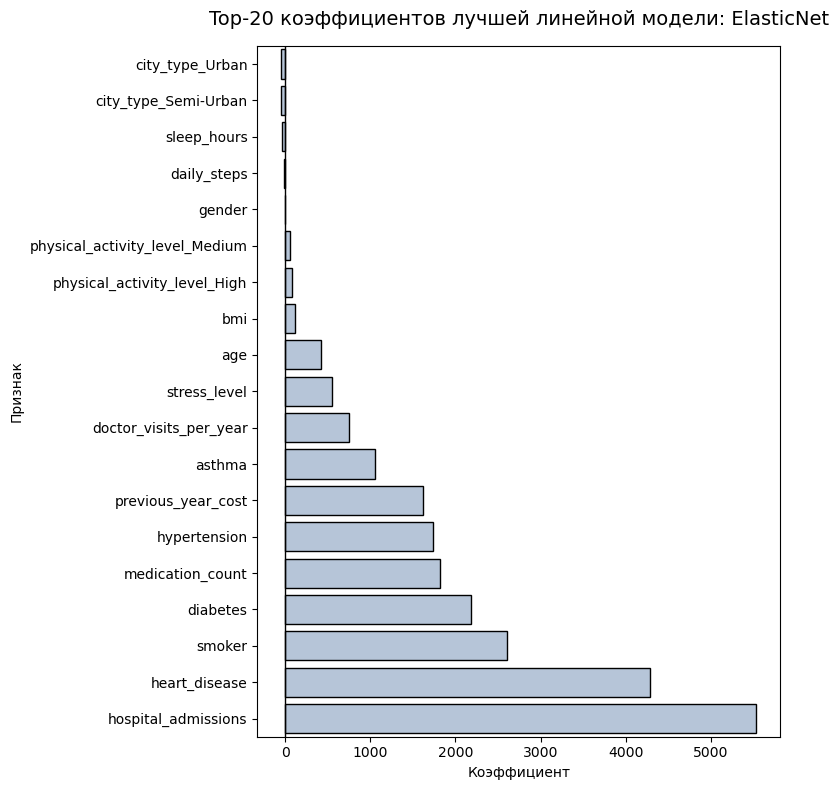

In [53]:
# Визуализация наиболее важных transformed-признаков

top_n = 20
plot_coef_df = linear_coef_df.head(top_n).sort_values('coefficient')

plt.figure(figsize=(8, 8))

ax = sns.barplot(
    data=plot_coef_df,
    x='coefficient',
    y='feature',
    color='lightsteelblue',
    edgecolor='black'
)

ax.axvline(0, color='black', linewidth=1)
ax.set_title(
    f'Top-{top_n} коэффициентов лучшей линейной модели: {best_linear_name}',
    fontsize=14,
    pad=15
)
ax.set_xlabel('Коэффициент')
ax.set_ylabel('Признак')

plt.tight_layout()
plt.show()

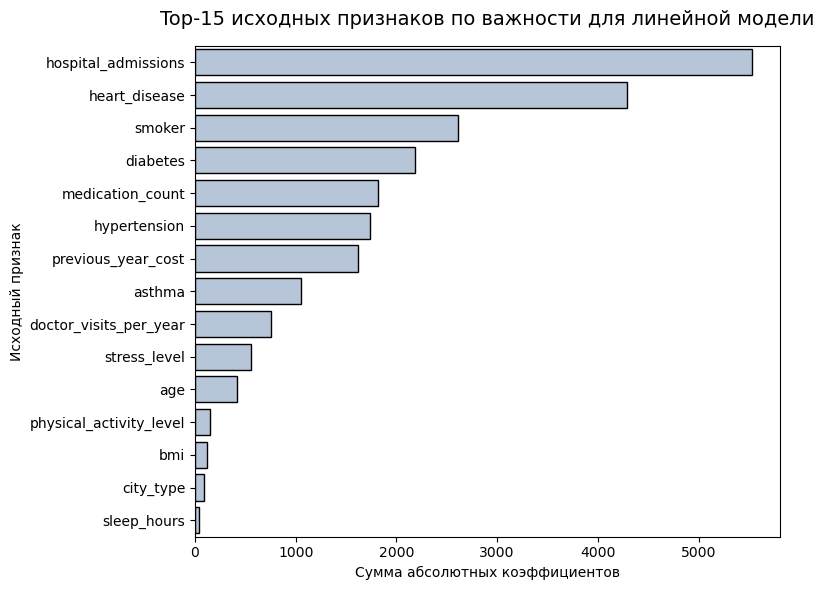

In [54]:
# Визуализация важности исходных признаков

top_n = 15
plot_original_importance = linear_original_feature_importance.head(top_n)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=plot_original_importance,
    x='importance',
    y='original_feature',
    color='lightsteelblue',
    edgecolor='black'
)

ax.set_title(
    f'Top-{top_n} исходных признаков по важности для линейной модели',
    fontsize=14,
    pad=15
)
ax.set_xlabel('Сумма абсолютных коэффициентов')
ax.set_ylabel('Исходный признак')

plt.tight_layout()
plt.show()

Краткая интерпретация коэффициентов линейной модели:

- Положительный коэффициент означает, что признак связан с увеличением прогнозируемых медицинских расходов.

- Отрицательный коэффициент означает, что признак связан со снижением прогнозируемых расходов при прочих равных условиях.

- Для числовых признаков коэффициенты интерпретируются с учётом масштабирования: они показывают изменение прогноза при увеличении признака примерно на одно стандартное отклонение.

- Для бинарных признаков коэффициент показывает разницу между значением `1` и `0`. Например, положительный коэффициент у `smoker` означает, что курящие пациенты в среднем имеют более высокий прогноз расходов.

- Для one-hot encoded признаков коэффициенты сравниваются с базовой категорией, которую удалил `OneHotEncoder` (Low и Rural)

- Основной вклад в прогноз дают медицинские признаки: `hospital_admissions`, `heart_disease`, `smoker`, `diabetes`, `medication_count`, `hypertension` и `previous_year_cost`.

- `hospital_admissions` имеет самый большой положительный коэффициент, то есть число госпитализаций сильнее всего повышает прогноз расходов среди признаков линейной модели.

- Небольшие отрицательные коэффициенты у `daily_steps`, `sleep_hours`, `physical_activity_level` и `city_type` говорят о слабом снижении прогноза, но эти эффекты заметно меньше, чем у медицинских факторов.

- Коэффициент `gender` почти равен нулю, поэтому после учёта остальных признаков пол практически не влияет на прогноз.

- В целом линейная модель подтверждает выводы EDA: основную роль играют медицинские признаки и история расходов, а демографические и поведенческие признаки имеют гораздо меньший вклад.

In [55]:
# Если лучшая модель использует feature selection,
# отдельно посмотрим, сколько transformed-призков было выбрано

if 'selector' in best_linear_model.named_steps:
    selector = best_linear_model.named_steps['selector']

    n_total_features = len(
        best_linear_model.named_steps['preprocessor'].get_feature_names_out()
    )
    n_selected_features = selector.get_support().sum()

    print(f'Всего transformed-признаков после preprocessing: {n_total_features}')
    print(f'Выбрано признаков: {n_selected_features}')
    print(f'Доля выбранных признаков: {n_selected_features / n_total_features:.2%}')
else:
    print('Лучшая линейная модель использует все transformed-признаки.')

Лучшая линейная модель использует все transformed-признаки.


In [56]:
# Лучший результат из линейных моделей

best_linear_cv_result = linear_cv_results.iloc[0].copy()

## Модели на основе деревьев

В этом блоке обучаем нелинейные модели: `RandomForestRegressor`, `HistGradientBoostingRegressor` и `CatBoostRegressor`.

Для признака `physical_activity_level` используем ordinal encoding, так как категории имеют естественный порядок: `Low < Medium < High`.  
Для `city_type` используем one-hot encoding, так как категории города не имеют естественного порядка.

Для `RandomForestRegressor` используем GridSearchCV.  
Для `HistGradientBoostingRegressor` и `CatBoostRegressor` используем Optuna, так как у этих моделей больше важных гиперпараметров.

Все промежуточные оценки качества проводятся на train через 5-fold cross-validation.

In [99]:
# Типы категориальных признаков для деревянных моделей

ordinal_features = ['physical_activity_level']
ordinal_categories = [['Low', 'Medium', 'High']]

nominal_categorical_features = ['city_type']

catboost_cat_features = ['city_type', 'physical_activity_level']

### 1. Random Forest

In [60]:
# Preprocessing для Random Forest и HistGradientBoosting
# Масштабирование не используем: деревья не чувствительны к масштабу признаков

def make_sklearn_tree_preprocessor(
    numeric_features,
    binary_features,
    ordinal_features,
    nominal_categorical_features
):
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])

    binary_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    ordinal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ])

    nominal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(
            drop=['Rural'],
            handle_unknown='ignore',
            sparse_output=False
        ))
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_features),
            ('binary', binary_pipeline, binary_features),
            ('ordinal', ordinal_pipeline, ordinal_features),
            ('nominal', nominal_pipeline, nominal_categorical_features)
        ],
        remainder='drop',
        verbose_feature_names_out=True
    )


def make_sklearn_tree_pipeline(model):
    return Pipeline([
        ('bmi_cleaner', BMICleaner(min_bmi=BMI_MIN_THRESHOLD)),
        ('preprocessor', make_sklearn_tree_preprocessor(
            numeric_features=numeric_features,
            binary_features=binary_features,
            ordinal_features=ordinal_features,
            nominal_categorical_features=nominal_categorical_features
        )),
        ('model', model)
    ])

In [62]:
# Параметры для RF подбираем через GridSearchCV

rf_pipeline = make_sklearn_tree_pipeline(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

rf_param_grid = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [6, 8, 10, 12],
    'model__min_samples_split': [5, 10, 100],
    'model__min_samples_leaf': [3, 10, 50],
    'model__max_features': ['sqrt', None]
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=scoring,
    refit='mae',
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f'Best CV MAE: {-rf_search.best_score_:.4f}')
print(f'Best params: {rf_search.best_params_}')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best CV MAE: 1021.9950
Best params: {'model__max_depth': 12, 'model__max_features': None, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [63]:
rf_cv_result = get_best_grid_metrics(
    rf_search,
    model_name='RandomForestRegressor'
)

rf_cv_result

model           RandomForestRegressor
CV_MAE_mean               1021.995024
CV_MAE_std                  18.025597
CV_RMSE_mean              1361.158898
CV_RMSE_std                 22.022872
CV_R2_mean                   0.961244
CV_R2_std                     0.00358
CV_MAPE_mean                 0.058009
CV_MAPE_std                  0.001063
dtype: object

### 2. HistGradientBoostingRegressor

In [93]:
# Функция для оценки pipeline на CV, которую используем внутри optuna objective

def evaluate_pipeline_cv_mae(pipeline, X, y, cv, trial=None):
    fold_mae = []

    for fold_id, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx].copy()
        y_fold_valid = y.iloc[valid_idx].copy()

        fold_model = clone(pipeline)
        fold_model.fit(X_fold_train, y_fold_train)

        y_fold_pred = fold_model.predict(X_fold_valid)
        mae = mean_absolute_error(y_fold_valid, y_fold_pred)

        fold_mae.append(mae)

        if trial is not None:
            trial.report(np.mean(fold_mae), step=fold_id)

            if trial.should_prune():
                raise optuna.TrialPruned()

    return np.mean(fold_mae)


def make_hgb_pipeline_from_params(params):
    model = HistGradientBoostingRegressor(
        **params,
        max_iter=5000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=50,
        tol=1.0,
        scoring='neg_mean_absolute_error',
        random_state=RANDOM_STATE
    )

    return make_sklearn_tree_pipeline(model)


def hgb_objective(trial):
    params = {
        'loss': trial.suggest_categorical(
            'loss',
            ['squared_error', 'absolute_error']
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.20,
            log=True
        ),
        'max_leaf_nodes': trial.suggest_int(
            'max_leaf_nodes',
            8,
            127
        ),
        'max_depth': trial.suggest_categorical(
            'max_depth',
            [None, 6, 8, 10, 15]
        ),
        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf',
            5,
            150
        ),
        'l2_regularization': trial.suggest_float(
            'l2_regularization',
            1e-8,
            100.0,
            log=True
        ),
        'max_bins': trial.suggest_int(
            'max_bins',
            64,
            255
        ),
        'max_features': trial.suggest_float(
            'max_features',
            0.5,
            1.0
        )
    }

    pipeline = make_hgb_pipeline_from_params(params)

    return evaluate_pipeline_cv_mae(
        pipeline=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        trial=trial
    )

In [94]:
# Запуск Optuna для HistGradientBoostingRegressor

N_TRIALS_HGB = 30

if OPTUNA_AVAILABLE:
    hgb_study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2)
    )

    hgb_study.optimize(
        hgb_objective,
        n_trials=N_TRIALS_HGB,
        show_progress_bar=True
    )

    print(f'Best CV MAE: {hgb_study.best_value:.4f}')
    print(f'Best params: {hgb_study.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

Best CV MAE: 288.0927
Best params: {'loss': 'squared_error', 'learning_rate': 0.07815765780952179, 'max_leaf_nodes': 9, 'max_depth': None, 'min_samples_leaf': 28, 'l2_regularization': 1.5866293303745274e-07, 'max_bins': 225, 'max_features': 0.8501439166248974}


In [95]:
# Финальная CV-оценка лучшей HGB-конфигурации по всем метрикам

best_hgb_params = {
    **hgb_study.best_params,
}

best_hgb_pipeline = make_hgb_pipeline_from_params(best_hgb_params)

In [96]:
hgb_cv_result = cross_validate_regression_model(
    model=best_hgb_pipeline,
    X=X_train,
    y=y_train,
    model_name='HistGradientBoostingRegressor',
    cv=cv,
    scoring=scoring
)

hgb_cv_result

model           HistGradientBoostingRegressor
CV_MAE_mean                        288.092705
CV_MAE_std                           9.414153
CV_RMSE_mean                       513.700823
CV_RMSE_std                         45.312095
CV_R2_mean                           0.994408
CV_R2_std                            0.001283
CV_MAPE_mean                         0.015791
CV_MAPE_std                          0.000239
dtype: object

In [97]:
# Обучаем лучшую HGB-модель на всём train
best_hgb_pipeline.fit(X_train, y_train)

hgb_model = best_hgb_pipeline.named_steps['model']

print(f'Max iterations: {hgb_model.max_iter}')
print(f'Actual iterations: {hgb_model.n_iter_}')
print(f'Early stopping used: {hgb_model.do_early_stopping_}')

Max iterations: 5000
Actual iterations: 622
Early stopping used: True


### 3. CatBoost

Для CatBoost используем отдельную CV-функцию, чтобы early stopping был реализован корректно. На каждом фолде CatBoost получает eval_set, состоящий только из validation-части текущего CV-fold.

In [104]:
# Preprocessing для CatBoost
# physical_activity_level кодируем как ordinal-признак
# city_type оставляем категориальным признаком для нативной обработки CatBoost

class CatBoostMixedPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        numeric_features,
        binary_features,
        catboost_cat_features
    ):
        self.numeric_features = numeric_features
        self.binary_features = binary_features
        self.catboost_cat_features = catboost_cat_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X_out = pd.DataFrame(index=X.index)

        # Числовые признаки оставляем как есть
        X_out[self.numeric_features] = X[self.numeric_features]

        # Бинарные признаки тоже оставляем как 0/1
        X_out[self.binary_features] = X[self.binary_features]

        # Категориальные признаки оставляем категориальными для CatBoost
        for col in self.catboost_cat_features:
            X_out[col] = X[col].astype('object').where(X[col].notna(), 'Missing')

        return X_out[
            self.numeric_features
            + self.binary_features
            + self.catboost_cat_features
        ]
    
    
def make_catboost_preprocessor():
    return Pipeline([
        ('bmi_cleaner', BMICleaner(min_bmi=BMI_MIN_THRESHOLD)),
        ('catboost_preprocessor', CatBoostMixedPreprocessor(
            numeric_features=numeric_features,
            binary_features=binary_features,
            catboost_cat_features=catboost_cat_features
        ))
    ])


def make_catboost_model(
    params,
    iterations=3000,
    early_stopping_rounds=None
):
    model_params = {
        'iterations': iterations,
        'loss_function': 'RMSE',
        'eval_metric': 'MAE',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1,
        'cat_features': catboost_cat_features
    }

    if early_stopping_rounds is not None:
        model_params['early_stopping_rounds'] = early_stopping_rounds

    model_params.update(params)

    return CatBoostRegressor(**model_params)


def evaluate_catboost_params_cv(
    params,
    X,
    y,
    cv,
    max_iterations=5000,
    early_stopping_rounds=50,
    trial=None
):
    fold_metrics = []
    fold_best_iterations = []

    for fold_id, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx].copy()
        y_fold_valid = y.iloc[valid_idx].copy()

        # Preprocessing обучается только на train-части текущего фолда
        fold_preprocessor = make_catboost_preprocessor()

        X_fold_train_prepared = fold_preprocessor.fit_transform(X_fold_train)
        X_fold_valid_prepared = fold_preprocessor.transform(X_fold_valid)

        model = make_catboost_model(
            params=params,
            iterations=max_iterations,
            early_stopping_rounds=early_stopping_rounds
        )

        model.fit(
            X_fold_train_prepared,
            y_fold_train,
            eval_set=(X_fold_valid_prepared, y_fold_valid),
            use_best_model=True
        )

        y_fold_pred = model.predict(X_fold_valid_prepared)

        metrics = calculate_regression_metrics(
            y_fold_valid,
            y_fold_pred
        )

        fold_metrics.append(metrics)
        fold_best_iterations.append(model.tree_count_)

        if trial is not None:
            current_mae = np.mean([m['MAE'] for m in fold_metrics])
            trial.report(current_mae, step=fold_id)

            if trial.should_prune():
                raise optuna.TrialPruned()

    result = {
        'CV_MAE_mean': np.mean([m['MAE'] for m in fold_metrics]),
        'CV_MAE_std': np.std([m['MAE'] for m in fold_metrics]),
        'CV_RMSE_mean': np.mean([m['RMSE'] for m in fold_metrics]),
        'CV_RMSE_std': np.std([m['RMSE'] for m in fold_metrics]),
        'CV_R2_mean': np.mean([m['R2'] for m in fold_metrics]),
        'CV_R2_std': np.std([m['R2'] for m in fold_metrics]),
        'CV_MAPE_mean': np.mean([m['MAPE'] for m in fold_metrics]),
        'CV_MAPE_std': np.std([m['MAPE'] for m in fold_metrics]),
        'best_iteration_mean': np.mean(fold_best_iterations),
        'best_iteration_median': int(np.median(fold_best_iterations))
    }

    return result


def catboost_objective(trial):
    params = {
        'depth': trial.suggest_int(
            'depth',
            3,
            10
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.20,
            log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg',
            1e-2,
            100.0,
            log=True
        ),
        'random_strength': trial.suggest_float(
            'random_strength',
            0.0,
            10.0
        ),
        'bagging_temperature': trial.suggest_float(
            'bagging_temperature',
            0.0,
            10.0
        ),
        'border_count': trial.suggest_int(
            'border_count',
            32,
            255
        )
    }

    cv_result = evaluate_catboost_params_cv(
        params=params,
        X=X_train,
        y=y_train,
        cv=cv,
        max_iterations=5000,
        early_stopping_rounds=50,
        trial=trial
    )

    return cv_result['CV_MAE_mean']

In [105]:
# Запуск Optuna для CatBoost

N_TRIALS_CATBOOST = 5

if OPTUNA_AVAILABLE and CATBOOST_AVAILABLE:
    catboost_study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2)
    )

    catboost_study.optimize(
        catboost_objective,
        n_trials=N_TRIALS_CATBOOST,
        show_progress_bar=True
    )

    print(f'Best CV MAE: {catboost_study.best_value:.4f}')
    print(f'Best params: {catboost_study.best_params}')

  0%|          | 0/5 [00:00<?, ?it/s]

Best CV MAE: 43.2657
Best params: {'depth': 3, 'learning_rate': 0.13394334706750485, 'l2_leaf_reg': 2.5378155082656657, 'random_strength': 7.080725777960454, 'bagging_temperature': 0.20584494295802447, 'border_count': 249}


In [107]:
# Финальная CV-оценка CatBoost с лучшими параметрами

best_catboost_cv_metrics = evaluate_catboost_params_cv(
    params=catboost_study.best_params,
    X=X_train,
    y=y_train,
    cv=cv,
    max_iterations=5000,
    early_stopping_rounds=50
)

catboost_cv_result = pd.Series({
    'model': 'CatBoostRegressor',
    'CV_MAE_mean': best_catboost_cv_metrics['CV_MAE_mean'],
    'CV_MAE_std': best_catboost_cv_metrics['CV_MAE_std'],
    'CV_RMSE_mean': best_catboost_cv_metrics['CV_RMSE_mean'],
    'CV_RMSE_std': best_catboost_cv_metrics['CV_RMSE_std'],
    'CV_R2_mean': best_catboost_cv_metrics['CV_R2_mean'],
    'CV_R2_std': best_catboost_cv_metrics['CV_R2_std'],
    'CV_MAPE_mean': best_catboost_cv_metrics['CV_MAPE_mean'],
    'CV_MAPE_std': best_catboost_cv_metrics['CV_MAPE_std']
})

catboost_cv_result

model           CatBoostRegressor
CV_MAE_mean              43.26567
CV_MAE_std               4.467223
CV_RMSE_mean           159.979407
CV_RMSE_std             99.754766
CV_R2_mean               0.999223
CV_R2_std                0.001008
CV_MAPE_mean             0.002223
CV_MAPE_std              0.000207
dtype: object

In [109]:
# Финально обучаем CatBoost на всём train
# Количество итераций берём из best_iteration по CV

best_catboost_iterations = int(best_catboost_cv_metrics['best_iteration_median'])

best_catboost_pipeline = Pipeline([
    ('catboost_preprocessing', make_catboost_preprocessor()),
    ('model', make_catboost_model(
        params=catboost_study.best_params,
        iterations=best_catboost_iterations,
        early_stopping_rounds=None
    ))
])

best_catboost_pipeline.fit(X_train, y_train)

print(f'CatBoost final iterations: {best_catboost_iterations}')

CatBoost final iterations: 3931


### Сравнение моделей на основе деревьев

In [110]:
# Собираем CV-результаты деревянных моделей

tree_cv_results = pd.DataFrame([
    rf_cv_result,
    hgb_cv_result,
    catboost_cv_result
])

tree_cv_results = tree_cv_results.sort_values(
    by='CV_MAE_mean',
    ascending=True
).reset_index(drop=True)

tree_cv_results.round(4)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,CV_MAPE_mean,CV_MAPE_std
0,CatBoostRegressor,43.2657,4.4672,159.9794,99.7548,0.9992,0.0010,0.0022,0.0002
1,HistGradientBoostingRegressor,288.0927,9.4142,513.7008,45.3121,0.9944,0.0013,0.0158,0.0002
2,RandomForestRegressor,1021.9950,18.0256,1361.1589,22.0229,0.9612,0.0036,0.0580,0.0011


In [111]:
# Сохраняем fitted-модели для финального сравнения на test позже

tree_fitted_models = {
    'RandomForestRegressor': rf_search.best_estimator_,
    'HistGradientBoostingRegressor': best_hgb_pipeline,
    'CatBoostRegressor': best_catboost_pipeline
}

In [112]:
# Добавляем результаты в общую таблицу CV-результатов

tree_model_names = set(tree_cv_results['model'])

cv_results = [
    row for row in cv_results
    if row.get('model') not in tree_model_names
]

cv_results.extend(tree_cv_results.to_dict('records'))

all_cv_results = (
    pd.DataFrame(cv_results)
    .sort_values('CV_MAE_mean')
    .reset_index(drop=True)
)

all_cv_results.round(4)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,CV_MAPE_mean,CV_MAPE_std
0,CatBoostRegressor,43.2657,4.4672,159.9794,99.7548,0.9992,0.0010,0.0022,0.0002
1,HistGradientBoostingRegressor,288.0927,9.4142,513.7008,45.3121,0.9944,0.0013,0.0158,0.0002
2,RandomForestRegressor,1021.9950,18.0256,1361.1589,22.0229,0.9612,0.0036,0.0580,0.0011
3,ElasticNet,1039.6312,27.1966,1452.6805,71.0566,0.9561,0.0015,0.0542,0.0010
4,Ridge,1043.4573,29.5451,1415.1547,71.3368,0.9584,0.0019,0.0565,0.0016
5,Lasso,1055.3151,32.4218,1406.5457,72.4511,0.9589,0.0021,0.0583,0.0020
6,LinearRegression,1058.6745,32.6983,1405.7835,71.8959,0.9589,0.0021,0.0589,0.0021
7,LassoSelect + Ridge,1101.1743,47.3158,1495.5461,75.4129,0.9535,0.0020,0.0591,0.0025


### Анализ feature importance в деревянных моделях

In [119]:
def clean_transformed_feature_name(feature_name):
    return feature_name.split('__', 1)[-1]


def get_original_feature_name(transformed_feature_name, original_features):
    clean_name = clean_transformed_feature_name(transformed_feature_name)

    for feature in sorted(original_features, key=len, reverse=True):
        if clean_name == feature or clean_name.startswith(f'{feature}_'):
            return feature

    return clean_name


def aggregate_importance_by_original_feature(
    importance_df,
    importance_col='importance'
):
    importance_df = importance_df.copy()

    importance_df['original_feature'] = importance_df['feature'].apply(
        lambda name: get_original_feature_name(name, feature_cols)
    )

    return (
        importance_df
        .groupby('original_feature', as_index=False)
        .agg(
            importance=(importance_col, 'sum'),
            n_transformed_features=('feature', 'count')
        )
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )


def plot_feature_importance(
    importance_df,
    title,
    feature_col='feature',
    importance_col='importance',
    top_n=15
):
    plot_df = (
        importance_df
        .sort_values(importance_col, ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        data=plot_df,
        x=importance_col,
        y=feature_col,
        color='lightsteelblue',
        edgecolor='black'
    )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('Важность')
    ax.set_ylabel('Признак')

    plt.tight_layout()
    plt.show()

#### RF native

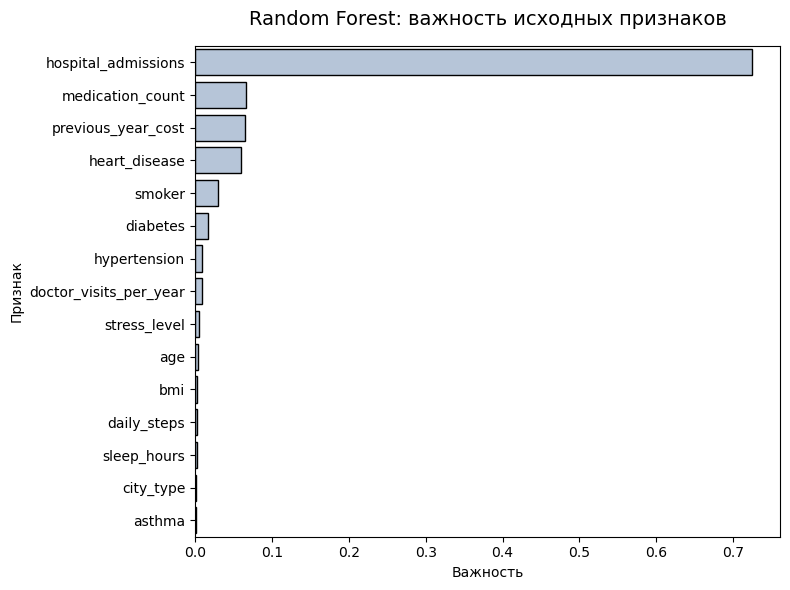

In [120]:
# Важность признаков Random Forest на основе impurity decrease
# ! Может быть смещён в сторону признаков с большим числом разбиений

rf_best_model = rf_search.best_estimator_

rf_feature_names = (
    rf_best_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

rf_importance = pd.DataFrame({
    'feature': [clean_transformed_feature_name(name) for name in rf_feature_names],
    'importance': rf_best_model.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

rf_original_importance = aggregate_importance_by_original_feature(
    rf_importance,
    importance_col='importance'
)

plot_feature_importance(
    rf_original_importance,
    title='Random Forest: важность исходных признаков',
    feature_col='original_feature',
    importance_col='importance',
    top_n=15
)

#### Permutation importance

In [121]:
# Permutation importance считаем на train
# Интерпретируем осторожно: это не финальная проверка качества, а анализ fitted-моделей

def get_permutation_importance_df(
    model,
    X,
    y,
    model_name,
    n_repeats=10
):
    perm_result = permutation_importance(
        model,
        X,
        y,
        scoring='neg_mean_absolute_error',
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': perm_result.importances_mean,
        'importance_std': perm_result.importances_std,
        'model': model_name
    }).sort_values('importance', ascending=False)

    return importance_df.reset_index(drop=True)


rf_permutation_importance = get_permutation_importance_df(
    model=rf_search.best_estimator_,
    X=X_train,
    y=y_train,
    model_name='RandomForestRegressor'
)

hgb_permutation_importance = get_permutation_importance_df(
    model=best_hgb_pipeline,
    X=X_train,
    y=y_train,
    model_name='HistGradientBoostingRegressor'
)

catboost_permutation_importance = get_permutation_importance_df(
    model=best_catboost_pipeline,
    X=X_train,
    y=y_train,
    model_name='CatBoostRegressor'
)

permutation_importance_all = pd.concat(
    [
        rf_permutation_importance,
        hgb_permutation_importance,
        catboost_permutation_importance
    ],
    ignore_index=True
)

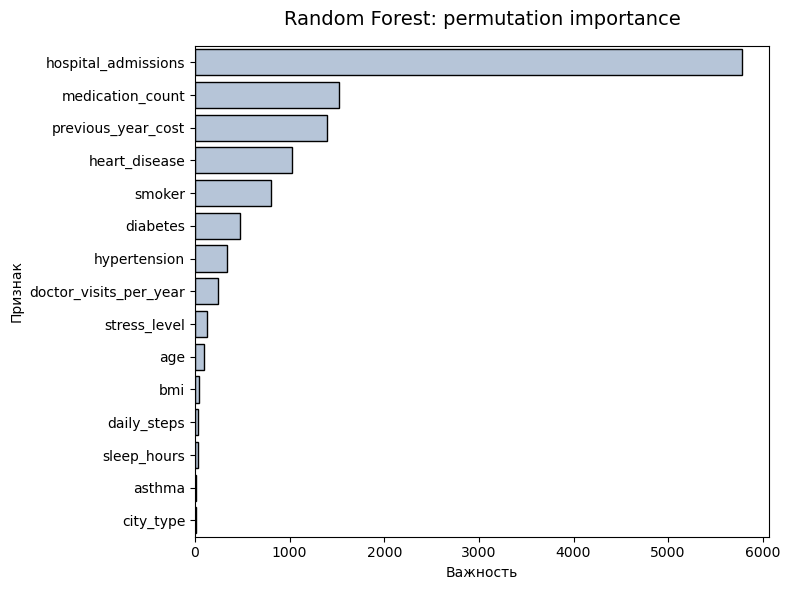

In [122]:
plot_feature_importance(
    rf_permutation_importance,
    title='Random Forest: permutation importance',
    feature_col='feature',
    importance_col='importance',
    top_n=15
)

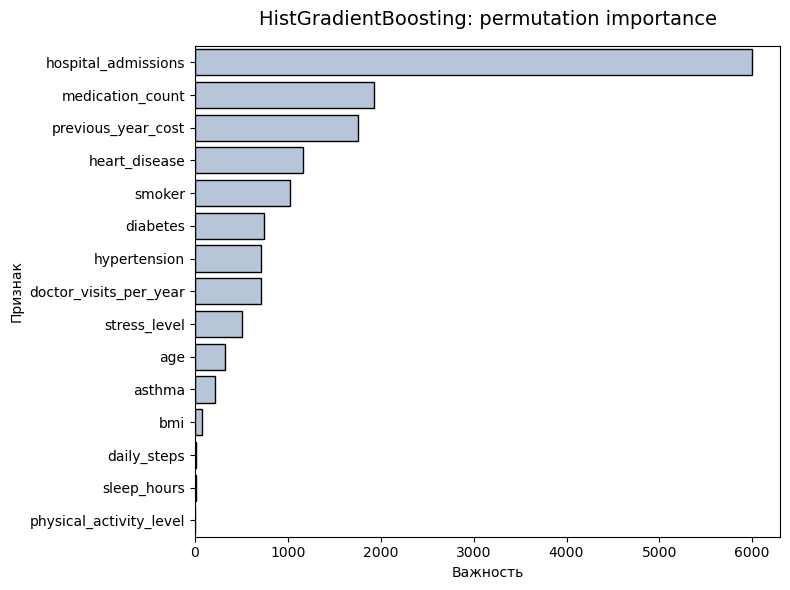

In [123]:
plot_feature_importance(
    hgb_permutation_importance,
    title='HistGradientBoosting: permutation importance',
    feature_col='feature',
    importance_col='importance',
    top_n=15
)

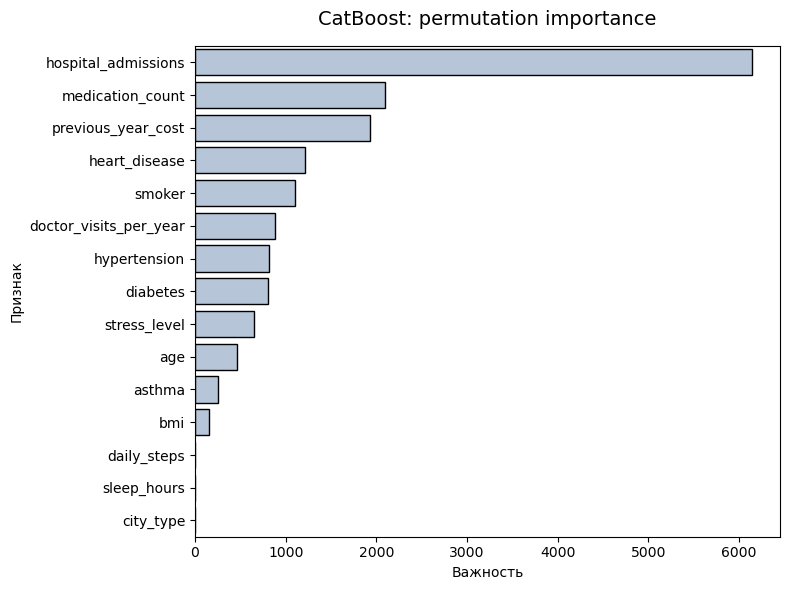

In [124]:
plot_feature_importance(
    catboost_permutation_importance,
    title='CatBoost: permutation importance',
    feature_col='feature',
    importance_col='importance',
    top_n=15
)

#### Caboost native

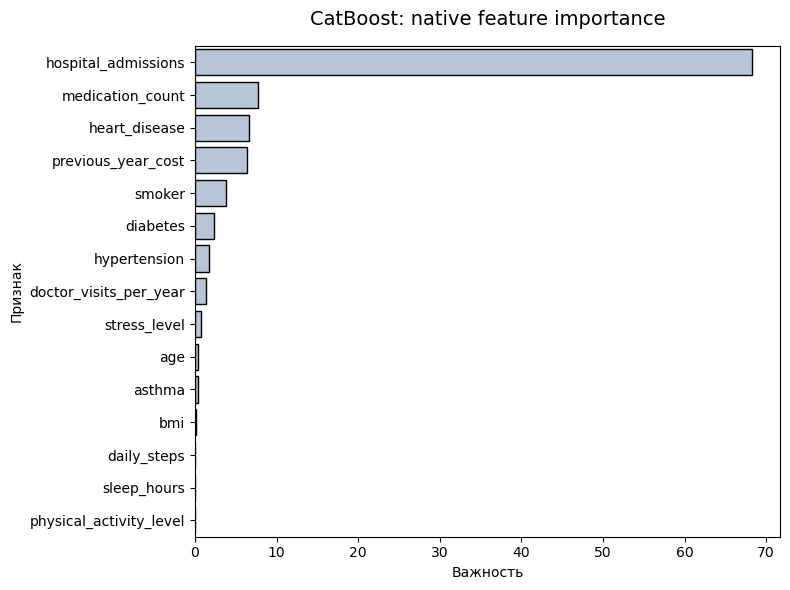

In [125]:
# Нативная важность признаков CatBoost
# CatBoost работает с исходными признаками, поэтому one-hot агрегация здесь не нужна

catboost_preprocessor = best_catboost_pipeline.named_steps['catboost_preprocessing']
catboost_model = best_catboost_pipeline.named_steps['model']

X_train_catboost_prepared = catboost_preprocessor.transform(X_train)

catboost_native_importance = pd.DataFrame({
    'feature': X_train_catboost_prepared.columns,
    'importance': catboost_model.get_feature_importance(type='PredictionValuesChange')
}).sort_values('importance', ascending=False).reset_index(drop=True)

plot_feature_importance(
    catboost_native_importance,
    title='CatBoost: native feature importance',
    feature_col='feature',
    importance_col='importance',
    top_n=15
)

#### SHAP importance

In [135]:
def get_catboost_shap_importance(
    fitted_catboost_pipeline,
    X,
    sample_size=700
):
    sample_size = min(sample_size, len(X))

    X_sample = X.sample(
        n=sample_size,
        random_state=RANDOM_STATE
    )

    preprocessor = fitted_catboost_pipeline.named_steps['catboost_preprocessing']
    model = fitted_catboost_pipeline.named_steps['model']

    X_sample_prepared = preprocessor.transform(X_sample)

    pool = Pool(
        X_sample_prepared,
        cat_features=catboost_cat_features
    )

    shap_values = model.get_feature_importance(
        pool,
        type='ShapValues'
    )

    # Последняя колонка — base value, её убираем
    shap_feature_values = shap_values[:, :-1]

    shap_importance = pd.DataFrame({
        'feature': X_sample_prepared.columns,
        'importance': np.abs(shap_feature_values).mean(axis=0)
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    return shap_importance, shap_feature_values, X_sample_prepared

C:\Users\dmitry.volobuev_inde\AppData\Local\Temp\ipykernel_4960\954300269.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


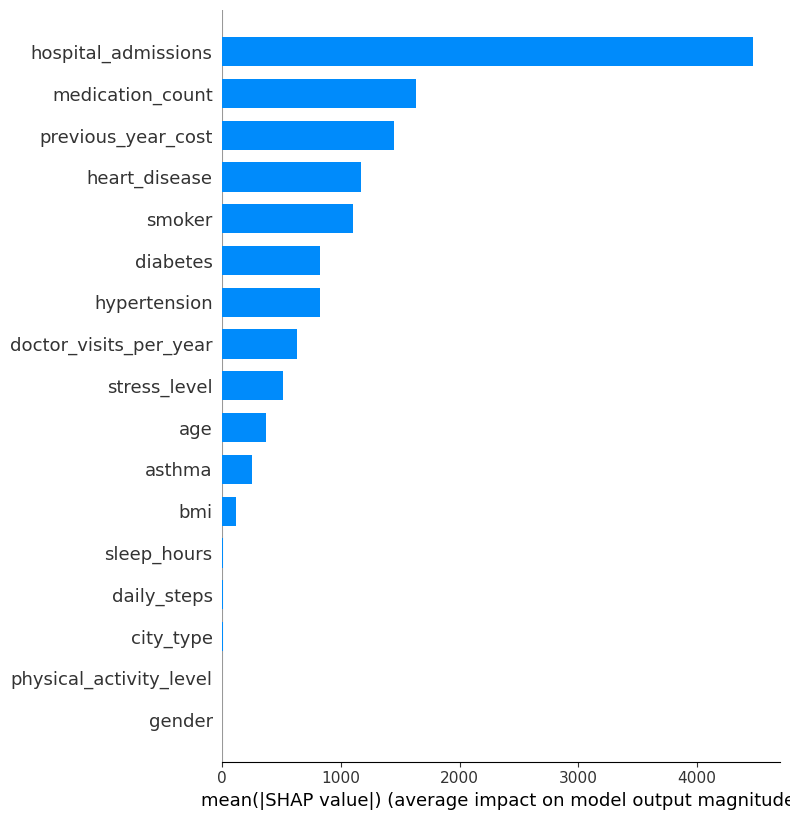

In [136]:
if SHAP_AVAILABLE and CATBOOST_AVAILABLE:
    catboost_shap_importance, catboost_shap_values, catboost_shap_X = (
        get_catboost_shap_importance(
            fitted_catboost_pipeline=best_catboost_pipeline,
            X=X_train,
            sample_size=1000
        )
    )
    
    shap.summary_plot(
        catboost_shap_values,
        catboost_shap_X,
        plot_type='bar',
        max_display=20
    )

По результатам SHAP-анализа часть признаков имеет почти нулевой вклад в прогноз.  
Проверим отдельную версию CatBoost только на признаках с заметной SHAP-важностью.

Цель этого блока — понять, можно ли упростить модель без потери качества.  
Все оценки по-прежнему проводятся только на train через кросс-валидацию.

In [139]:
SHAP_RELATIVE_THRESHOLD = 0.01  # оставляем признаки >= 1% от максимальной SHAP-важности
MIN_SELECTED_FEATURES = 8       # минимальное число признаков на случай слишком жёсткого порога

catboost_shap_ranking = (
    catboost_shap_importance
    .copy()
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

max_shap_importance = catboost_shap_ranking['importance'].max()
importance_threshold = max_shap_importance * SHAP_RELATIVE_THRESHOLD

selected_catboost_features = (
    catboost_shap_ranking
    .query('importance >= @importance_threshold')['feature']
    .tolist()
)

if len(selected_catboost_features) < MIN_SELECTED_FEATURES:
    selected_catboost_features = (
        catboost_shap_ranking
        .head(MIN_SELECTED_FEATURES)['feature']
        .tolist()
    )

dropped_catboost_features = [
    col for col in feature_cols
    if col not in selected_catboost_features
]

print(f'Выбрано признаков: {len(selected_catboost_features)}')
print(f'Исключено признаков: {len(dropped_catboost_features)}')
print()

print('Selected features:')
display(selected_catboost_features)

print('Dropped features:')
display(dropped_catboost_features)

Выбрано признаков: 12
Исключено признаков: 5

Selected features:


['hospital_admissions',
 'medication_count',
 'previous_year_cost',
 'heart_disease',
 'smoker',
 'diabetes',
 'hypertension',
 'doctor_visits_per_year',
 'stress_level',
 'age',
 'asthma',
 'bmi']

Dropped features:


['daily_steps',
 'sleep_hours',
 'gender',
 'physical_activity_level',
 'city_type']

In [140]:
selected_numeric_features = [
    col for col in numeric_features
    if col in selected_catboost_features
]

selected_binary_features = [
    col for col in binary_features
    if col in selected_catboost_features
]

selected_catboost_cat_features = [
    col for col in catboost_cat_features
    if col in selected_catboost_features
]

print('Selected numeric:', selected_numeric_features)
print('Selected binary:', selected_binary_features)
print('Selected categorical:', selected_catboost_cat_features)

Selected numeric: ['age', 'bmi', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'previous_year_cost', 'stress_level']
Selected binary: ['smoker', 'diabetes', 'hypertension', 'heart_disease', 'asthma']
Selected categorical: []


In [144]:
def make_selected_catboost_preprocessor():
    return Pipeline([
        ('bmi_cleaner', BMICleaner(min_bmi=BMI_MIN_THRESHOLD)),
        ('catboost_preprocessor', CatBoostMixedPreprocessor(
            numeric_features=selected_numeric_features,
            binary_features=selected_binary_features,
            catboost_cat_features=selected_catboost_cat_features
        ))
    ])


def make_selected_catboost_model(
    params,
    iterations=3000,
    early_stopping_rounds=None
):
    model_params = {
        'iterations': iterations,
        'loss_function': 'RMSE',
        'eval_metric': 'MAE',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1,
        'cat_features': selected_catboost_cat_features
    }

    if early_stopping_rounds is not None:
        model_params['early_stopping_rounds'] = early_stopping_rounds

    model_params.update(params)

    return CatBoostRegressor(**model_params)


def evaluate_selected_catboost_params_cv(
    params,
    X,
    y,
    cv,
    max_iterations=5000,
    early_stopping_rounds=50,
    trial=None
):
    fold_metrics = []
    fold_best_iterations = []

    for fold_id, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx].copy()
        y_fold_valid = y.iloc[valid_idx].copy()

        # Preprocessing обучается только на train-части текущего фолда
        fold_preprocessor = make_selected_catboost_preprocessor()

        X_fold_train_prepared = fold_preprocessor.fit_transform(X_fold_train)
        X_fold_valid_prepared = fold_preprocessor.transform(X_fold_valid)

        model = make_selected_catboost_model(
            params=params,
            iterations=max_iterations,
            early_stopping_rounds=early_stopping_rounds
        )

        model.fit(
            X_fold_train_prepared,
            y_fold_train,
            eval_set=(X_fold_valid_prepared, y_fold_valid),
            use_best_model=True
        )

        y_fold_pred = model.predict(X_fold_valid_prepared)

        metrics = calculate_regression_metrics(
            y_fold_valid,
            y_fold_pred
        )

        fold_metrics.append(metrics)
        fold_best_iterations.append(model.tree_count_)

        if trial is not None:
            current_mae = np.mean([m['MAE'] for m in fold_metrics])
            trial.report(current_mae, step=fold_id)

            if trial.should_prune():
                raise optuna.TrialPruned()

    return {
        'CV_MAE_mean': np.mean([m['MAE'] for m in fold_metrics]),
        'CV_MAE_std': np.std([m['MAE'] for m in fold_metrics]),
        'CV_RMSE_mean': np.mean([m['RMSE'] for m in fold_metrics]),
        'CV_RMSE_std': np.std([m['RMSE'] for m in fold_metrics]),
        'CV_R2_mean': np.mean([m['R2'] for m in fold_metrics]),
        'CV_R2_std': np.std([m['R2'] for m in fold_metrics]),
        'CV_MAPE_mean': np.mean([m['MAPE'] for m in fold_metrics]),
        'CV_MAPE_std': np.std([m['MAPE'] for m in fold_metrics]),
        'best_iteration_mean': np.mean(fold_best_iterations),
        'best_iteration_median': int(np.median(fold_best_iterations))
    }


def selected_catboost_objective(trial):
    params = {
        'depth': trial.suggest_int(
            'depth',
            3,
            10
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.20,
            log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg',
            1e-2,
            100.0,
            log=True
        ),
        'random_strength': trial.suggest_float(
            'random_strength',
            0.0,
            10.0
        ),
        'bagging_temperature': trial.suggest_float(
            'bagging_temperature',
            0.0,
            10.0
        ),
        'border_count': trial.suggest_int(
            'border_count',
            32,
            255
        )
    }

    cv_result = evaluate_selected_catboost_params_cv(
        params=params,
        X=X_train,
        y=y_train,
        cv=cv,
        max_iterations=5000,
        early_stopping_rounds=50,
        trial=trial
    )

    return cv_result['CV_MAE_mean']

In [145]:
# Запуск Optuna для сокращённого CatBoost

N_TRIALS_SELECTED_CATBOOST = 5

if OPTUNA_AVAILABLE and CATBOOST_AVAILABLE:
    selected_catboost_study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2)
    )

    selected_catboost_study.optimize(
        selected_catboost_objective,
        n_trials=N_TRIALS_SELECTED_CATBOOST,
        show_progress_bar=True
    )

    print(f'Best CV MAE: {selected_catboost_study.best_value:.4f}')
    print(f'Best params: {selected_catboost_study.best_params}')

  0%|          | 0/5 [00:00<?, ?it/s]

Best CV MAE: 42.6528
Best params: {'depth': 3, 'learning_rate': 0.13394334706750485, 'l2_leaf_reg': 2.5378155082656657, 'random_strength': 7.080725777960454, 'bagging_temperature': 0.20584494295802447, 'border_count': 249}


In [146]:
best_selected_catboost_cv_metrics = evaluate_selected_catboost_params_cv(
    params=selected_catboost_study.best_params,
    X=X_train,
    y=y_train,
    cv=cv,
    max_iterations=5000,
    early_stopping_rounds=50
)

selected_catboost_cv_result = pd.Series({
    'model': 'CatBoostRegressor_SHAP_selected',
    'CV_MAE_mean': best_selected_catboost_cv_metrics['CV_MAE_mean'],
    'CV_MAE_std': best_selected_catboost_cv_metrics['CV_MAE_std'],
    'CV_RMSE_mean': best_selected_catboost_cv_metrics['CV_RMSE_mean'],
    'CV_RMSE_std': best_selected_catboost_cv_metrics['CV_RMSE_std'],
    'CV_R2_mean': best_selected_catboost_cv_metrics['CV_R2_mean'],
    'CV_R2_std': best_selected_catboost_cv_metrics['CV_R2_std'],
    'CV_MAPE_mean': best_selected_catboost_cv_metrics['CV_MAPE_mean'],
    'CV_MAPE_std': best_selected_catboost_cv_metrics['CV_MAPE_std'],
    'n_features': len(selected_catboost_features)
})

selected_catboost_cv_result

model           CatBoostRegressor_SHAP_selected
CV_MAE_mean                           42.652767
CV_MAE_std                             3.577767
CV_RMSE_mean                         163.545802
CV_RMSE_std                           93.172368
CV_R2_mean                             0.999231
CV_R2_std                              0.000929
CV_MAPE_mean                           0.002121
CV_MAPE_std                            0.000159
n_features                                   12
dtype: object

In [147]:
best_selected_catboost_iterations = int(best_selected_catboost_cv_metrics['best_iteration_median'])

best_selected_catboost_pipeline = Pipeline([
    ('catboost_preprocessing', make_selected_catboost_preprocessor()),
    ('model', make_selected_catboost_model(
        params=selected_catboost_study.best_params,
        iterations=best_selected_catboost_iterations,
        early_stopping_rounds=None
    ))
])

best_selected_catboost_pipeline.fit(X_train, y_train)

print(f'Selected CatBoost final iterations: {best_selected_catboost_iterations}')

Selected CatBoost final iterations: 3882


In [148]:
selected_model_name = selected_catboost_cv_result['model']

cv_results = [
    row for row in cv_results
    if row.get('model') != selected_model_name
]

cv_results.append(selected_catboost_cv_result.to_dict())

all_cv_results = (
    pd.DataFrame(cv_results)
    .sort_values('CV_MAE_mean')
    .reset_index(drop=True)
)

all_cv_results.round(4)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,CV_MAPE_mean,CV_MAPE_std,n_features
0,CatBoostRegressor_SHAP_selected,42.6528,3.5778,163.5458,93.1724,0.9992,0.0009,0.0021,0.0002,12.0
1,CatBoostRegressor,43.2657,4.4672,159.9794,99.7548,0.9992,0.0010,0.0022,0.0002,NaN
2,HistGradientBoostingRegressor,288.0927,9.4142,513.7008,45.3121,0.9944,0.0013,0.0158,0.0002,NaN
3,RandomForestRegressor,1021.9950,18.0256,1361.1589,22.0229,0.9612,0.0036,0.0580,0.0011,NaN
4,ElasticNet,1039.6312,27.1966,1452.6805,71.0566,0.9561,0.0015,0.0542,0.0010,NaN
5,Ridge,1043.4573,29.5451,1415.1547,71.3368,0.9584,0.0019,0.0565,0.0016,NaN
6,Lasso,1055.3151,32.4218,1406.5457,72.4511,0.9589,0.0021,0.0583,0.0020,NaN
7,LinearRegression,1058.6745,32.6983,1405.7835,71.8959,0.9589,0.0021,0.0589,0.0021,NaN
8,LassoSelect + Ridge,1101.1743,47.3158,1495.5461,75.4129,0.9535,0.0020,0.0591,0.0025,NaN


In [149]:
tree_fitted_models['CatBoostRegressor_SHAP_selected'] = best_selected_catboost_pipeline

# Оценка на тесте

На этом этапе впервые используем отложенную тестовую выборку.  
Все модели уже были подобраны и обучены на train, поэтому test используется только для финальной оценки качества.

Для статистически более корректного сравнения считаем:

- основные метрики на test;
- bootstrap 95% confidence intervals для метрик;
- paired bootstrap-сравнение моделей по MAE.

In [152]:
# Финальный набор моделей для test-сравнения
# При необходимости можно убрать или добавить модели в этот словарь

final_models = {
    f'BestLinear_{best_linear_name}': best_linear_model,
    'RandomForestRegressor': tree_fitted_models['RandomForestRegressor'],
    'HistGradientBoostingRegressor': tree_fitted_models['HistGradientBoostingRegressor'],
    'CatBoostRegressor': tree_fitted_models['CatBoostRegressor']
}

# Добавляем сокращённую CatBoost-модель, если она была обучена
if 'CatBoostRegressor_SHAP_selected' in tree_fitted_models:
    final_models['CatBoostRegressor_SHAP_selected'] = tree_fitted_models[
        'CatBoostRegressor_SHAP_selected'
    ]

list(final_models.keys())

['BestLinear_ElasticNet',
 'RandomForestRegressor',
 'HistGradientBoostingRegressor',
 'CatBoostRegressor',
 'CatBoostRegressor_SHAP_selected']

In [153]:
# Получаем test-предсказания и считаем метрики

test_predictions = {}
test_results = []

for model_name, model in final_models.items():
    y_pred = model.predict(X_test)

    test_predictions[model_name] = y_pred

    metrics = calculate_regression_metrics(y_test, y_pred)
    metrics['model'] = model_name

    test_results.append(metrics)

test_results = (
    pd.DataFrame(test_results)
    [['model', 'MAE', 'RMSE', 'R2', 'MAPE']]
    .sort_values('MAE')
    .reset_index(drop=True)
)

test_results.round(4)

,model,MAE,RMSE,R2,MAPE
0,CatBoostRegressor,35.3957,130.7828,0.9997,0.0018
1,CatBoostRegressor_SHAP_selected,37.2625,198.7169,0.9992,0.0018
2,HistGradientBoostingRegressor,286.9458,609.9783,0.9928,0.0151
3,RandomForestRegressor,992.4295,1337.0705,0.9654,0.0570
4,BestLinear_ElasticNet,1086.1841,1607.9003,0.9500,0.0551


In [154]:
# Bootstrap confidence intervals для test-метрик
# Bootstrap делается по объектам test set: на каждой итерации сэмплируем пары
# y_true / y_pred с возвращением и заново считаем метрики

def bootstrap_metric_ci(
    y_true,
    y_pred,
    metric_func,
    n_bootstrap=1000,
    ci=0.95,
    random_state=RANDOM_STATE
):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n = len(y_true)
    metric_values = []

    for _ in range(n_bootstrap):
        sample_idx = rng.choice(n, size=n, replace=True)
        metric_values.append(
            metric_func(y_true[sample_idx], y_pred[sample_idx])
        )

    alpha = 1 - ci

    return {
        'mean': np.mean(metric_values),
        'ci_lower': np.quantile(metric_values, alpha / 2),
        'ci_upper': np.quantile(metric_values, 1 - alpha / 2)
    }

In [158]:
# Считаем 95% CI для основных метрик каждой модели

metric_functions = {
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'R2': r2_score,
    'MAPE': mean_absolute_percentage_error
}

bootstrap_rows = []

for model_name, y_pred in test_predictions.items():
    for metric_name, metric_func in metric_functions.items():
        ci_result = bootstrap_metric_ci(
            y_true=y_test,
            y_pred=y_pred,
            metric_func=metric_func,
            n_bootstrap=1000
        )

        bootstrap_rows.append({
            'model': model_name,
            'metric': metric_name,
            'mean': ci_result['mean'],
            'ci_lower': ci_result['ci_lower'],
            'ci_upper': ci_result['ci_upper']
        })

test_metric_ci = pd.DataFrame(bootstrap_rows)

test_metric_ci.head()

,model,metric,mean,ci_lower,ci_upper
0,BestLinear_ElasticNet,MAE,1083.206977,1011.971215,1158.432421
1,BestLinear_ElasticNet,RMSE,1598.572387,1421.908259,1797.682915
2,BestLinear_ElasticNet,R2,0.950328,0.940629,0.958358
3,BestLinear_ElasticNet,MAPE,0.054988,0.052408,0.057621
4,RandomForestRegressor,MAE,991.306302,938.697072,1050.684923


In [159]:
# Удобная итоговая таблица: test-метрики + 95% CI

test_metric_ci_wide = (
    test_metric_ci
    .assign(
        value_with_ci=lambda d: (
            d['mean'].round(4).astype(str)
            + ' ['
            + d['ci_lower'].round(4).astype(str)
            + '; '
            + d['ci_upper'].round(4).astype(str)
            + ']'
        )
    )
    .pivot(
        index='model',
        columns='metric',
        values='value_with_ci'
    )
    .reset_index()
)

# Сортируем по MAE из обычной test-таблицы
model_order = test_results['model'].tolist()

test_metric_ci_wide['model'] = pd.Categorical(
    test_metric_ci_wide['model'],
    categories=model_order,
    ordered=True
)

test_metric_ci_wide = (
    test_metric_ci_wide
    .sort_values('model')
    .reset_index(drop=True)
)

test_metric_ci_wide

metric,model,MAE,MAPE,R2,RMSE
0,CatBoostRegressor,35.2624 [29.8481; 44.1302],0.0018 [0.0017; 0.002],0.9997 [0.9991; 1.0],117.6393 [42.7628; 215.9033]
1,CatBoostRegressor_SHAP_selected,37.0872 [28.6439; 49.9434],0.0018 [0.0016; 0.0021],0.9993 [0.9979; 1.0],176.7452 [48.7314; 330.4852]
2,HistGradientBoostingRegressor,286.156 [256.7833; 324.1235],0.0151 [0.0141; 0.0162],0.9929 [0.986; 0.997],591.2487 [381.3362; 863.4565]
3,RandomForestRegressor,991.3063 [938.6971; 1050.6849],0.0569 [0.0537; 0.0604],0.9654 [0.9606; 0.9695],1334.3801 [1246.4075; 1437.8639]
4,BestLinear_ElasticNet,1083.207 [1011.9712; 1158.4324],0.055 [0.0524; 0.0576],0.9503 [0.9406; 0.9584],1598.5724 [1421.9083; 1797.6829]


In [160]:
# Paired bootstrap-сравнение моделей по MAE
# Сравниваем каждую модель с лучшей моделью по test MAE
# Если CI для разницы MAE не включает 0, различие можно считать устойчивым

def paired_bootstrap_mae_difference(
    y_true,
    y_pred_model,
    y_pred_best,
    n_bootstrap=1000,
    ci=0.95,
    random_state=RANDOM_STATE
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred_model = np.asarray(y_pred_model)
    y_pred_best = np.asarray(y_pred_best)

    n = len(y_true)
    diffs = []

    for _ in range(n_bootstrap):
        sample_idx = rng.choice(n, size=n, replace=True)

        mae_model = mean_absolute_error(
            y_true[sample_idx],
            y_pred_model[sample_idx]
        )
        mae_best = mean_absolute_error(
            y_true[sample_idx],
            y_pred_best[sample_idx]
        )

        diffs.append(mae_model - mae_best)

    alpha = 1 - ci

    return {
        'mae_diff_mean': np.mean(diffs),
        'ci_lower': np.quantile(diffs, alpha / 2),
        'ci_upper': np.quantile(diffs, 1 - alpha / 2)
    }

In [161]:
# Сравниваем все модели с лучшей по test MAE

best_test_model_name = test_results.loc[0, 'model']
best_test_pred = test_predictions[best_test_model_name]

comparison_rows = []

for model_name, y_pred in test_predictions.items():
    if model_name == best_test_model_name:
        continue

    diff_result = paired_bootstrap_mae_difference(
        y_true=y_test,
        y_pred_model=y_pred,
        y_pred_best=best_test_pred,
        n_bootstrap=1000
    )

    comparison_rows.append({
        'model': model_name,
        'compared_with': best_test_model_name,
        'MAE_diff_vs_best': diff_result['mae_diff_mean'],
        'ci_lower': diff_result['ci_lower'],
        'ci_upper': diff_result['ci_upper']
    })

mae_bootstrap_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values('MAE_diff_vs_best')
    .reset_index(drop=True)
)

mae_bootstrap_comparison.round(4)

,model,compared_with,MAE_diff_vs_best,ci_lower,ci_upper
0,CatBoostRegressor_SHAP_selected,CatBoostRegressor,1.8247,-2.8695,7.1456
1,HistGradientBoostingRegressor,CatBoostRegressor,250.8935,225.9670,282.8984
2,RandomForestRegressor,CatBoostRegressor,956.0439,903.7448,1013.8518
3,BestLinear_ElasticNet,CatBoostRegressor,1047.9445,979.1535,1120.1476


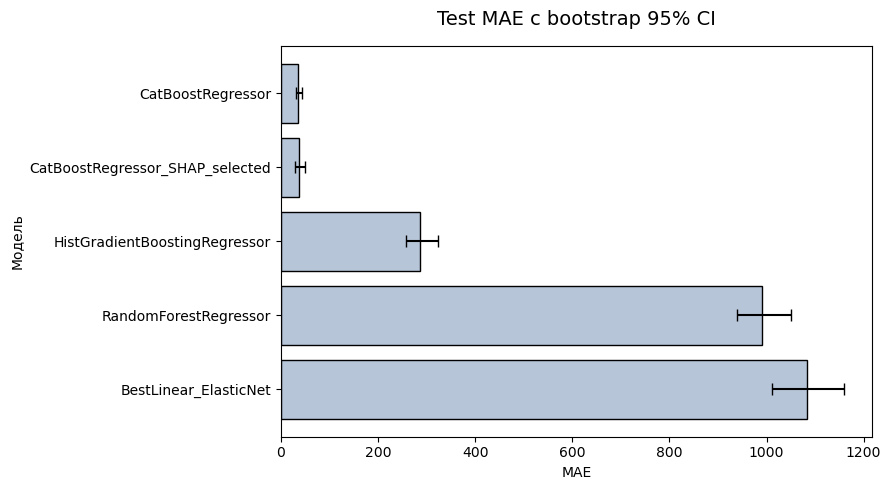

In [162]:
# Визуализация test MAE с bootstrap 95% CI

mae_ci = (
    test_metric_ci
    .query("metric == 'MAE'")
    .copy()
)

mae_ci['model'] = pd.Categorical(
    mae_ci['model'],
    categories=model_order,
    ordered=True
)

mae_ci = mae_ci.sort_values('model')

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=mae_ci,
    x='mean',
    y='model',
    color='lightsteelblue',
    edgecolor='black'
)

xerr = np.vstack([
    mae_ci['mean'] - mae_ci['ci_lower'],
    mae_ci['ci_upper'] - mae_ci['mean']
])

ax.errorbar(
    x=mae_ci['mean'],
    y=np.arange(len(mae_ci)),
    xerr=xerr,
    fmt='none',
    color='black',
    capsize=4
)

ax.set_title('Test MAE с bootstrap 95% CI', fontsize=14, pad=15)
ax.set_xlabel('MAE')
ax.set_ylabel('Модель')

plt.tight_layout()
plt.show()

- Лучшими по качеству на test оказались две модели: `CatBoostRegressor` и `CatBoostRegressor_SHAP_selected`.

- По результатам paired bootstrap-сравнения по метрике MAE статистически значимой разницы между ними не обнаружено: 95% доверительный интервал для разницы MAE включает 0.

- Это означает, что на имеющейся тестовой выборке нельзя утверждать, что полная CatBoost-модель лучше сокращённой версии на основе SHAP-отбора признаков.

- С учётом сопоставимого качества и меньшего числа признаков в качестве финальной модели можно выбрать `CatBoostRegressor_SHAP_selected` как более компактную и интерпретируемую.

In [164]:
def plot_regression_diagnostics(y_true, y_pred, model_name):
    residuals = y_true - y_pred
    abs_errors = np.abs(residuals)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Факт vs прогноз
    axes[0].scatter(y_true, y_pred, alpha=0.4, s=25, color='steelblue')
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    
    axes[0].plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle='--',
        color='red',
        linewidth=2
    )
    axes[0].set_title(f'{model_name}\nФакт vs прогноз')
    axes[0].set_xlabel('Фактические расходы')
    axes[0].set_ylabel('Прогноз')
    axes[0].grid(alpha=0.3)

    # 2. Остатки
    axes[1].scatter(y_pred, residuals, alpha=0.4, s=25, color='steelblue')
    axes[1].axhline(0, linestyle='--', color='red', linewidth=2)
    axes[1].set_title(f'{model_name}\nResidual plot')
    axes[1].set_xlabel('Прогноз')
    axes[1].set_ylabel('Остатки (y_true - y_pred)')
    axes[1].grid(alpha=0.3)

    # 3. Абсолютные ошибки
    sns.histplot(abs_errors, bins=30, kde=True, color='lightsteelblue',
                 edgecolor='black', ax=axes[2])
    axes[2].set_title(f'{model_name}\nРаспределение абсолютной ошибки')
    axes[2].set_xlabel('Absolute Error')
    axes[2].set_ylabel('Count')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

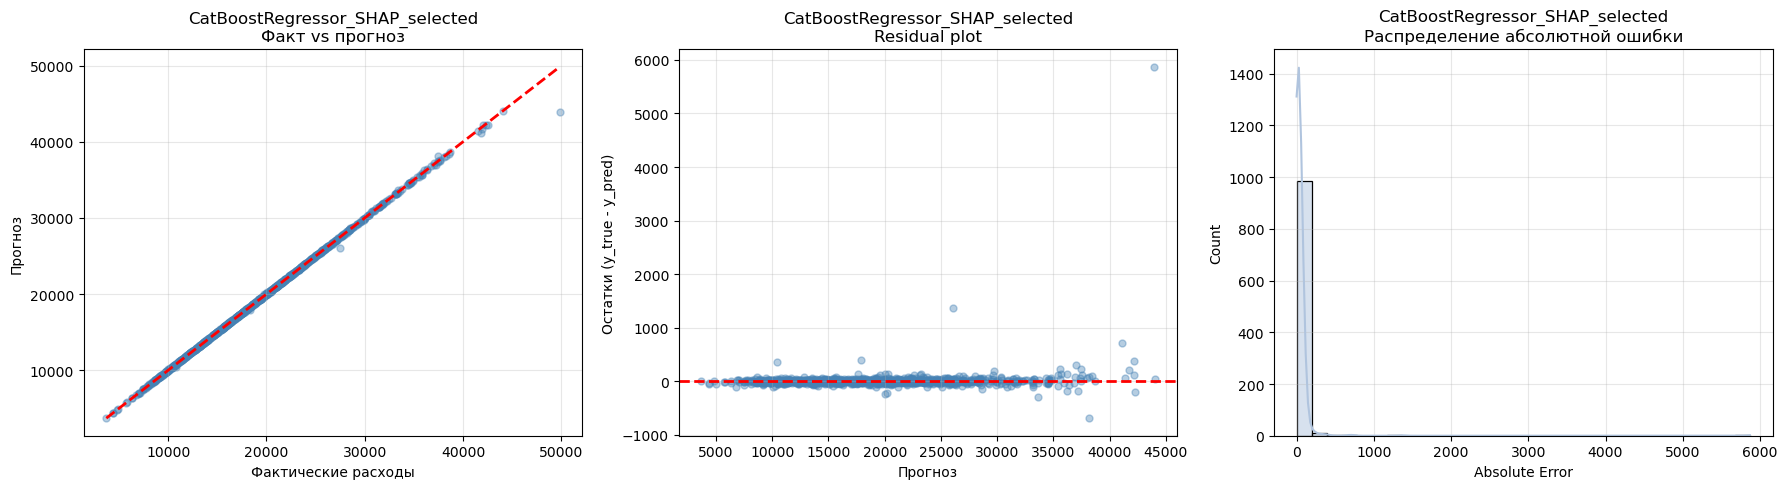

In [165]:
selected_model_name = 'CatBoostRegressor_SHAP_selected'
selected_pred = test_predictions[selected_model_name]

plot_regression_diagnostics(
    y_true=y_test,
    y_pred=selected_pred,
    model_name=selected_model_name
)